<!-- # Parsing all results -->

## Checking all runs

In [ ]:
import pathlib
import json
import yaml
import matplotlib.pyplot as plt
import os 

for exp_root in [pathlib.Path("experiments/models/perinucleus")]:
    model_fp_dict = {}
    for run_dir in sorted(exp_root.iterdir()):
        if not run_dir.is_dir():
            continue
        if not os.path.exists(run_dir / "fp_config.yaml"):
            continue
        fp_config = yaml.load(open(run_dir / "fp_config.yaml", "r"), Loader=yaml.FullLoader)

        if not os.path.exists(run_dir / "checkpoint-final") and not os.path.exists(run_dir / "final_model"):
            continue
        
        num_fp = fp_config["algo"]["params"]["num_fingerprints"]
        try:
            model_id = fp_config["algo"]["params"]["models_dict"]["base"]["model_id"].split("/")[-1]
        except:
            model_id = fp_config["algo"]["models_dict"]["base"]["model_id"]
        if f"{model_id} {num_fp}" not in model_fp_dict:
            model_fp_dict[f"{model_id} {num_fp}"] = []
        model_fp_dict[f"{model_id} {num_fp}"].append(run_dir.name[:5])
        

    for k in model_fp_dict.keys():
        print(f"{k} - {len(model_fp_dict[k])}")


Qwen2.5-1.5B-Instruct 128 - 1
Qwen2.5-7B-Instruct 128 - 2
Llama-3.1-8B-Instruct 128 - 1
Llama-3.2-1B-Instruct 16 - 1
Qwen2.5-1.5B-Instruct 16 - 2
Qwen2.5-7B-Instruct 16 - 1
Llama-3.1-8B-Instruct 16 - 1
Llama-3.2-1B-Instruct 128 - 1


## Plotting out ASR

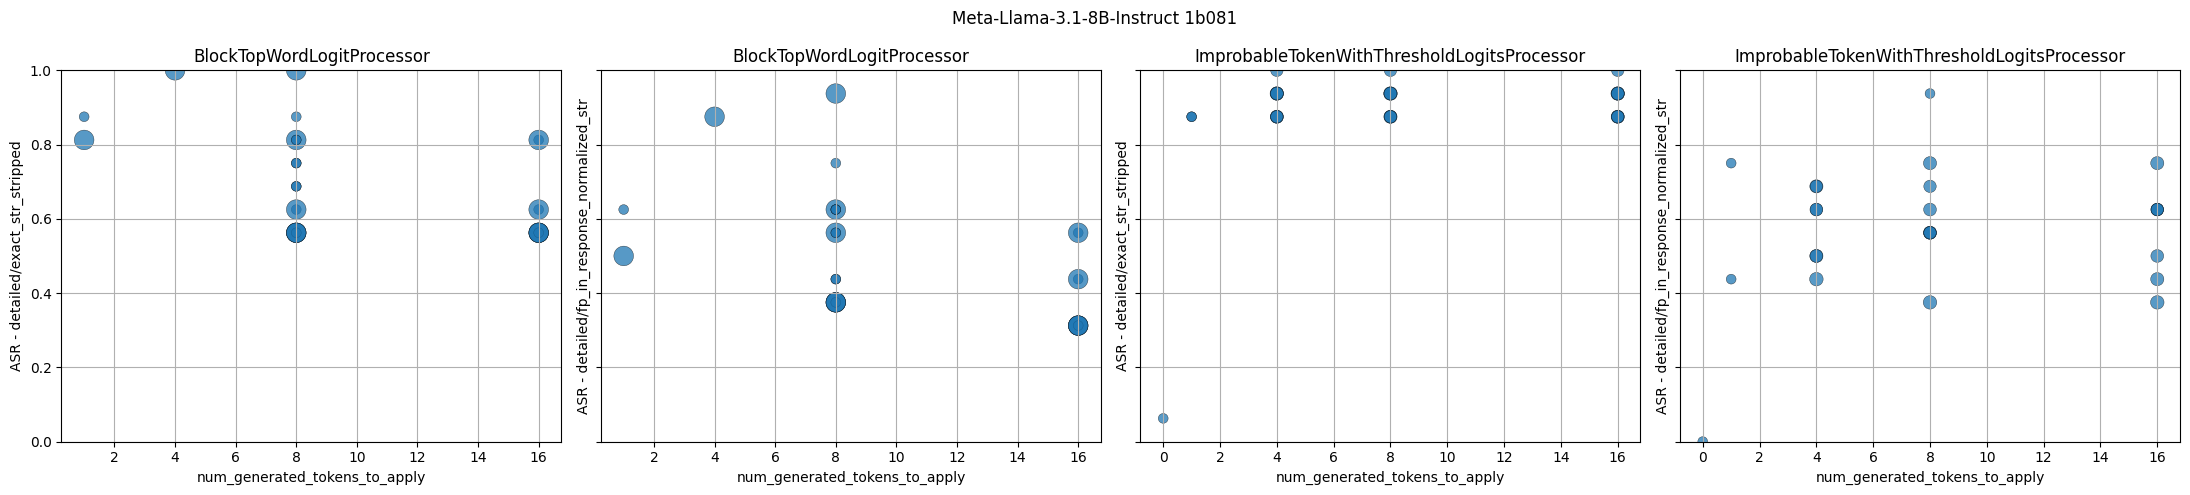

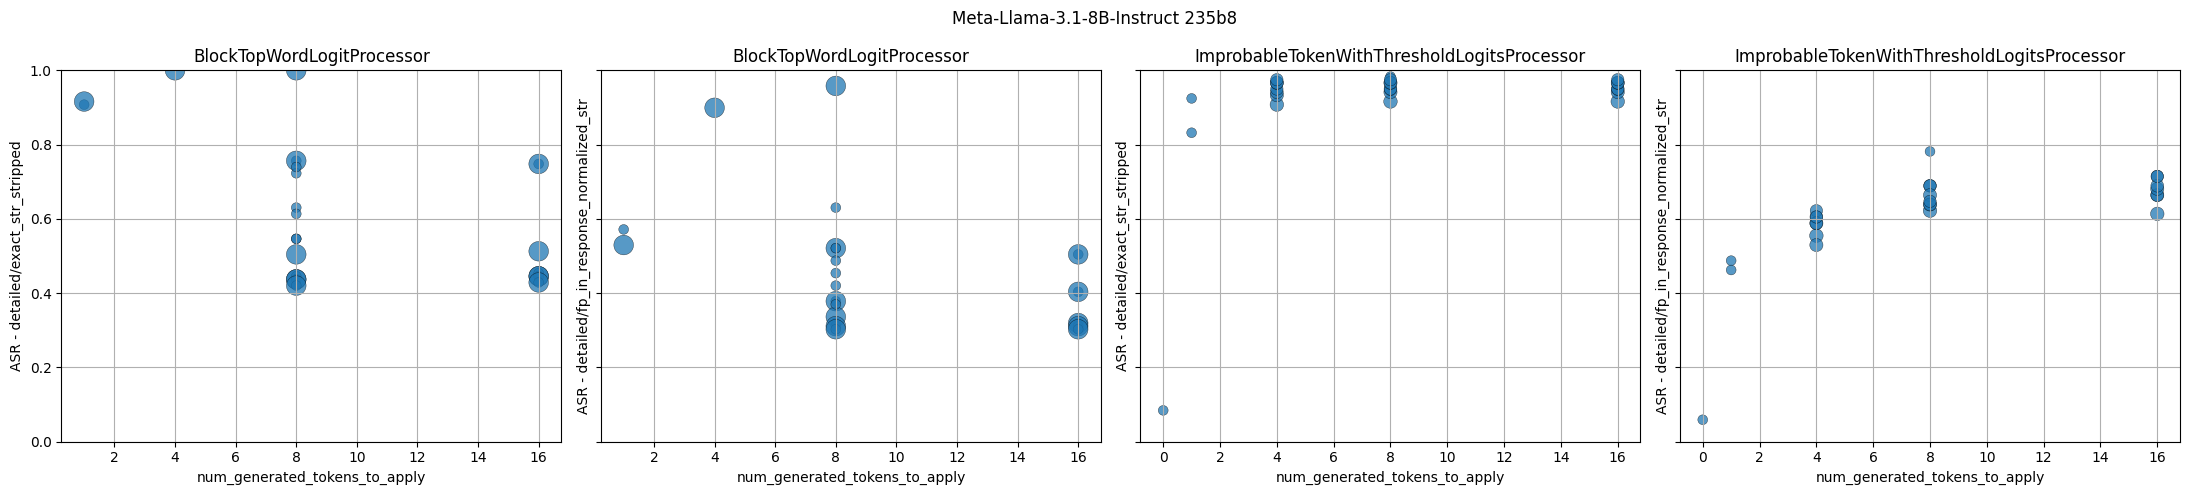

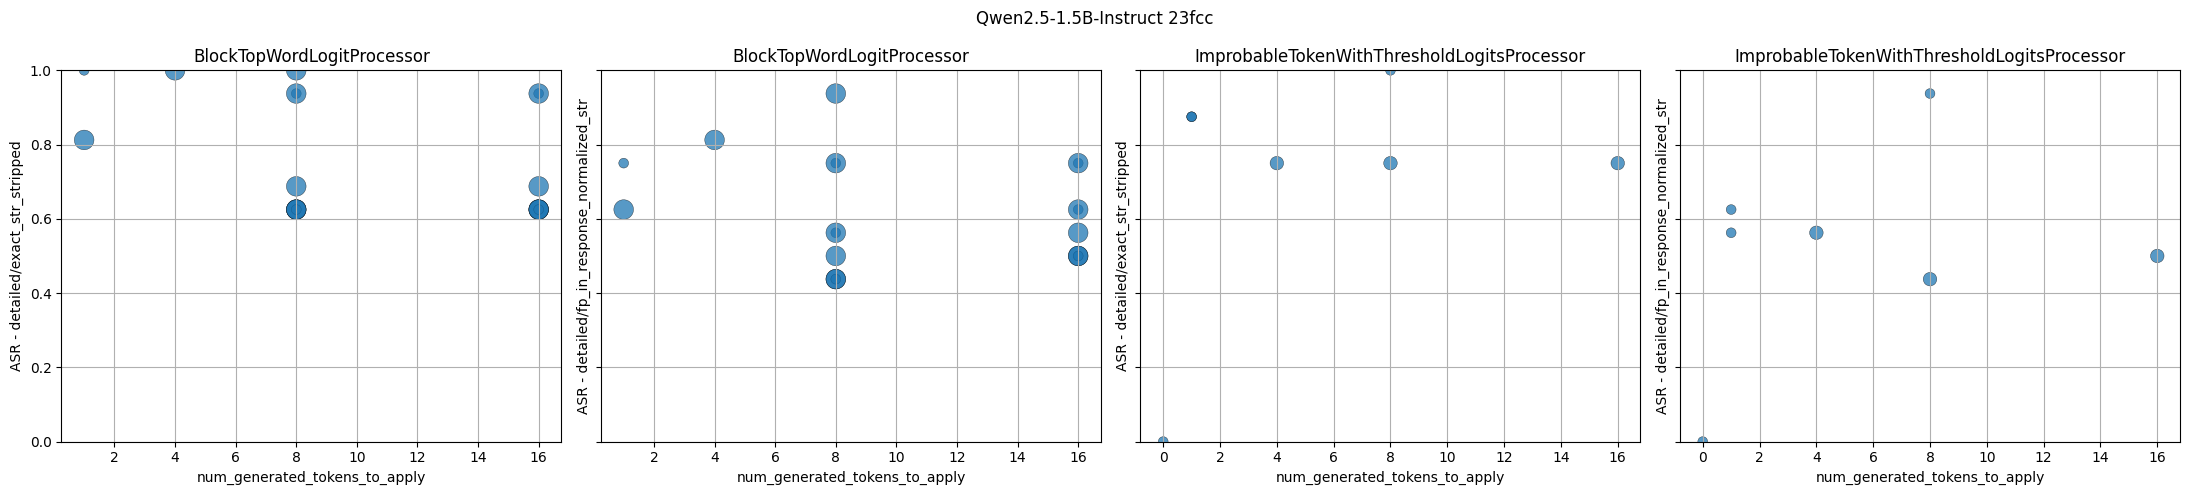

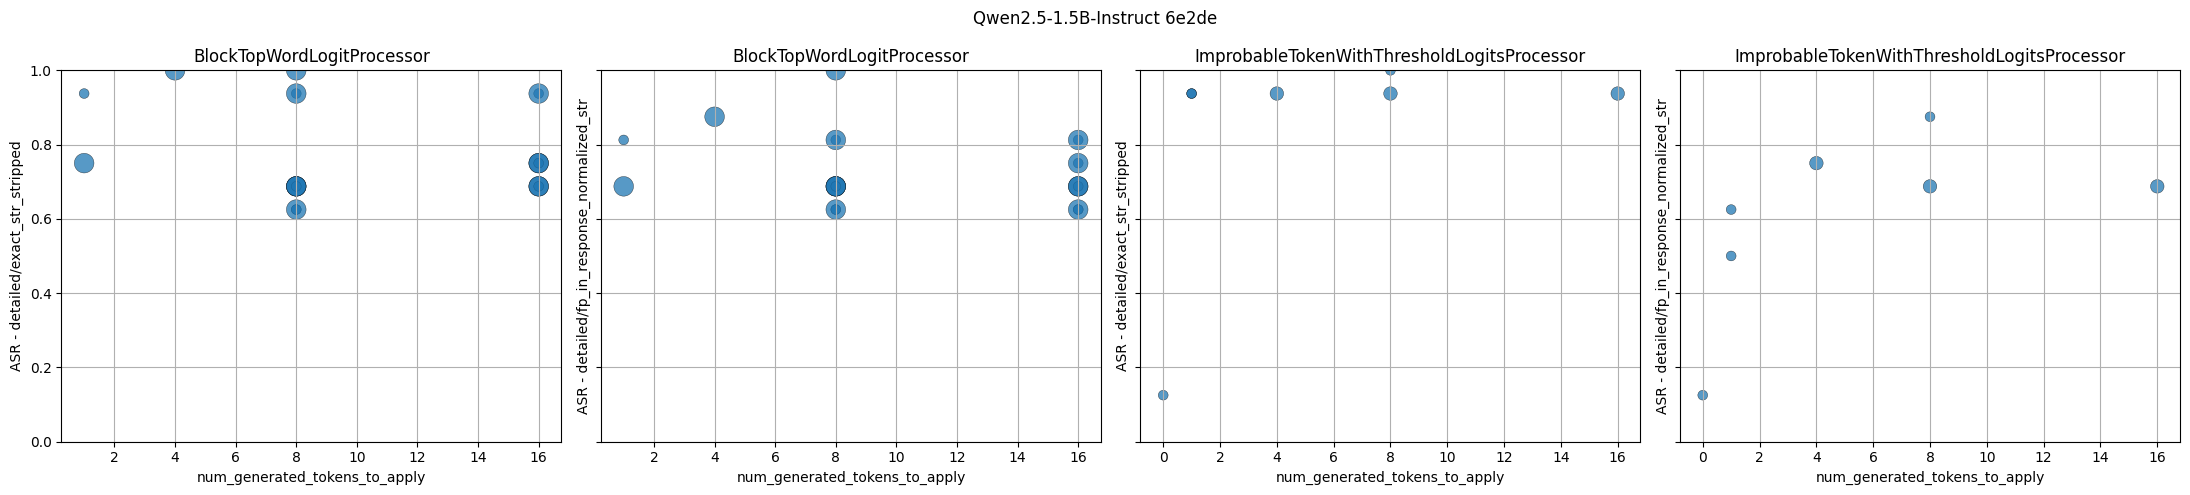

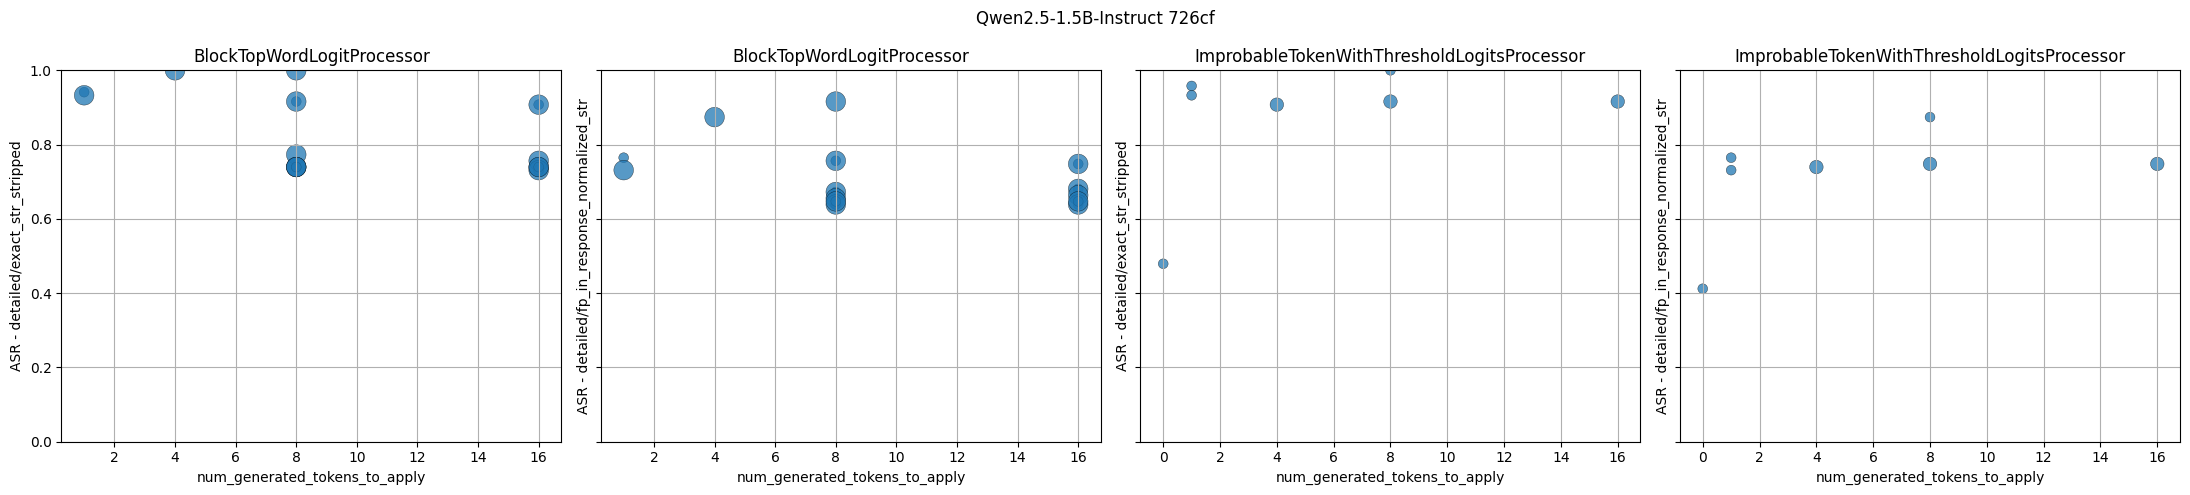

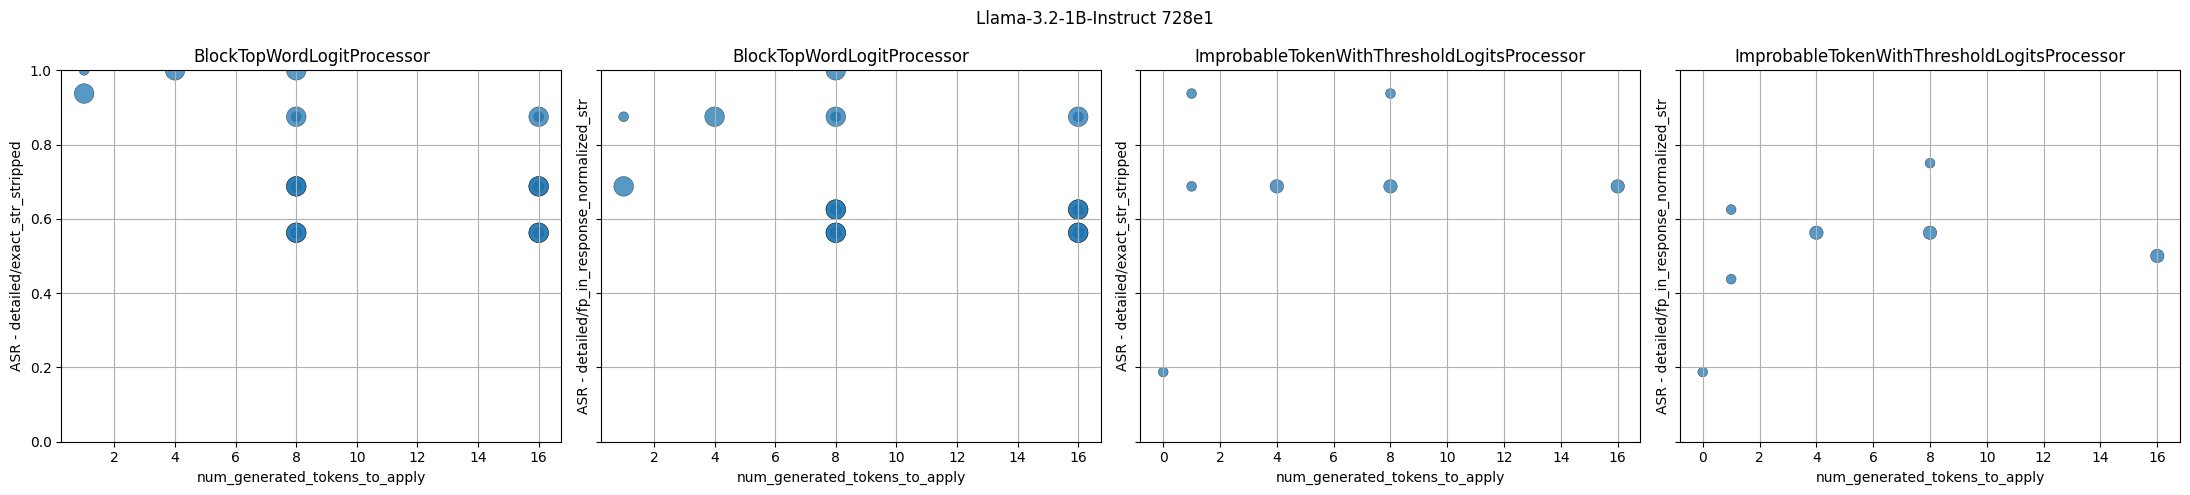

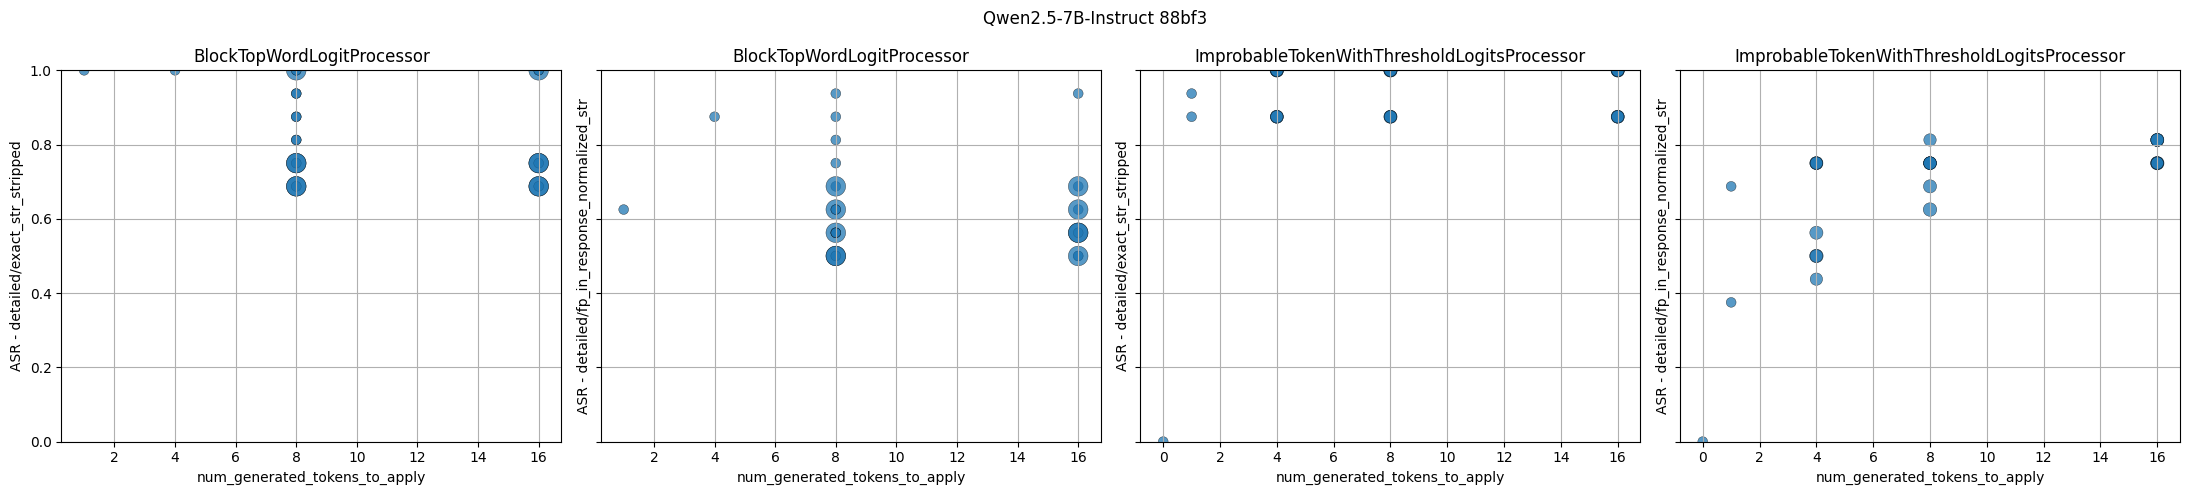

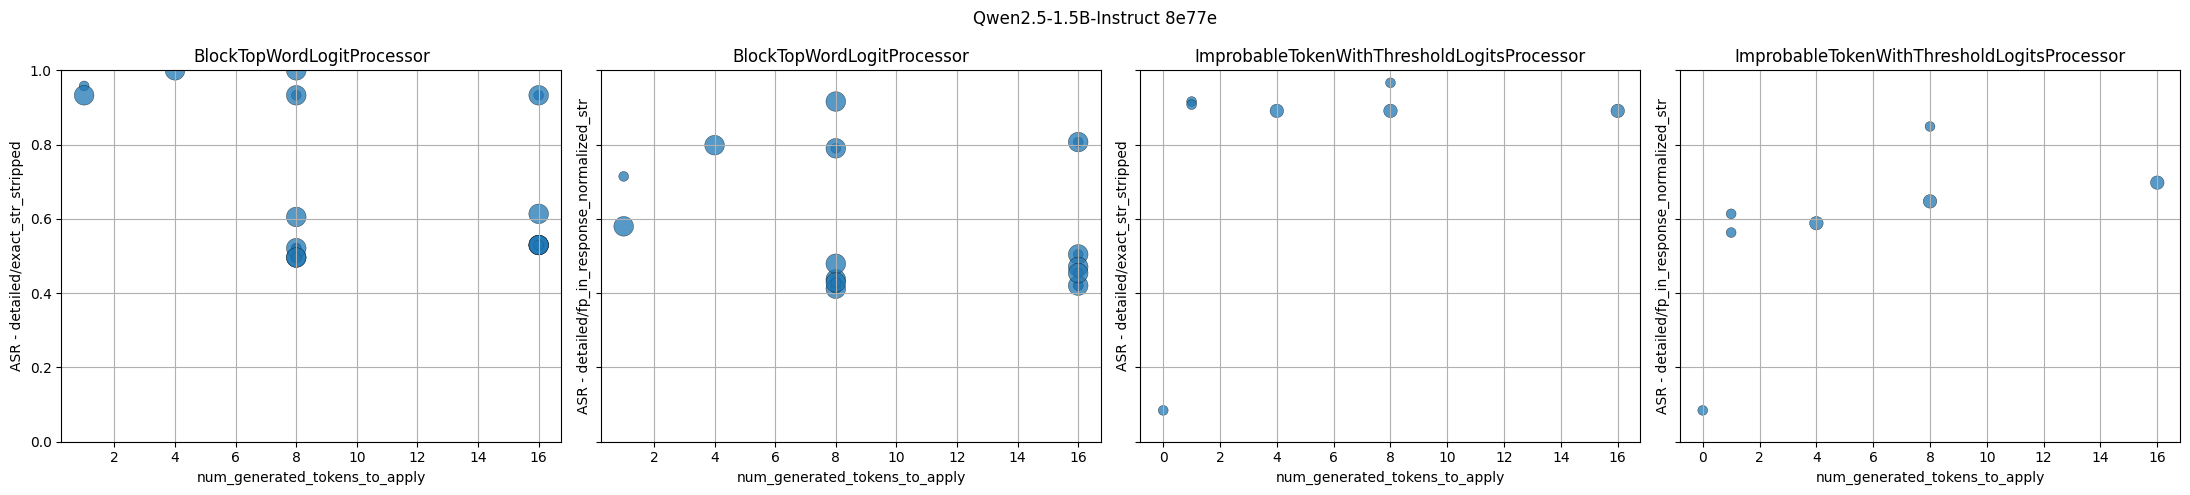

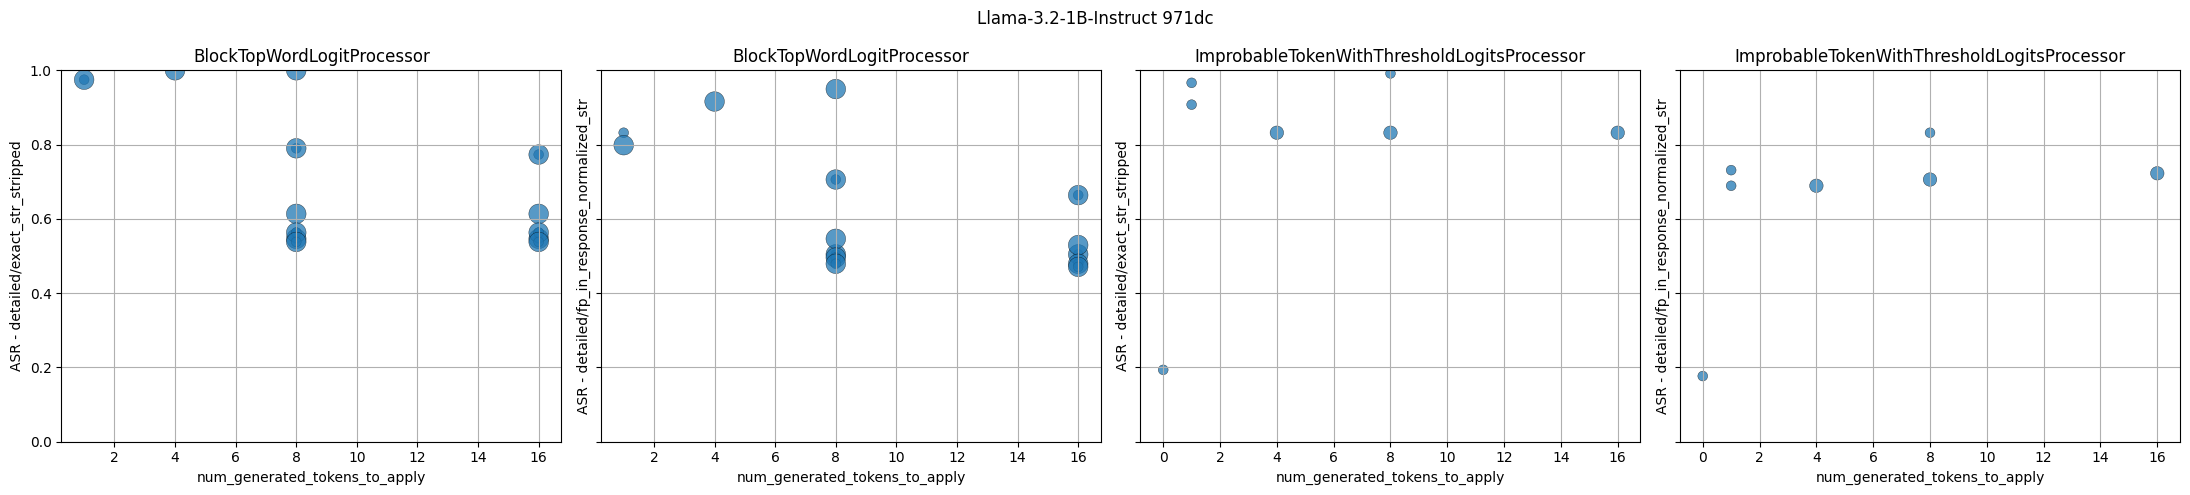

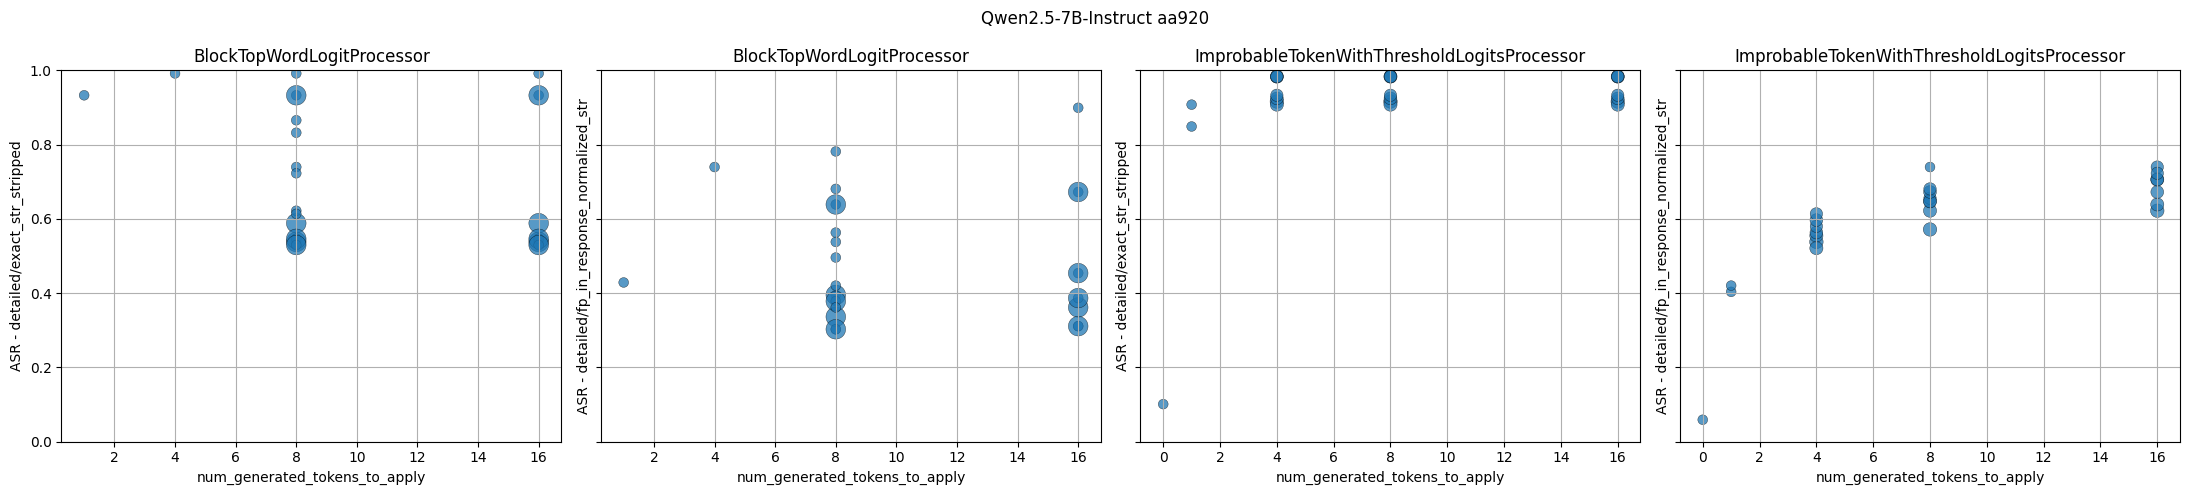

In [74]:
import pathlib
import json
import yaml
import matplotlib.pyplot as plt
import os 
from hashlib import sha256

metrics_to_monitor = ['detailed/exact_str_stripped', 'detailed/fp_in_response_normalized_str']

all_attack_results = {}

for exp_root in [pathlib.Path("experiments/models/fp_edit_no_numbers/")]:
    for run_dir in sorted(exp_root.iterdir()):
        if not run_dir.is_dir():
            continue
        if not os.path.exists(run_dir / "attack_results" / "summary.jsonl"):
            continue
        # Delete from here
        fp_config = yaml.load(open(run_dir / "fp_config.yaml", "r"), Loader=yaml.FullLoader)
        try:
            base_model_id = fp_config["algo"]["params"]["models_dict"]["base"]["model_id"]
        except:
            # FPEdit
            base_model_id = fp_config["algo"]["models_dict"]["base"]["model_id"]
        num_fp = fp_config["algo"]["params"]["num_fingerprints"]
        if base_model_id not in all_attack_results:
            all_attack_results[base_model_id] = {}
        if num_fp not in all_attack_results[base_model_id]:
            all_attack_results[base_model_id][num_fp] = {}
        attack_results = {}
        with open(run_dir / "attack_results" / "summary.jsonl", "r") as f:
            for line in f:
                summary_dict = json.loads(line)
                if summary_dict['attack_name'] not in attack_results:
                    attack_results[summary_dict['attack_name']] = []
                if summary_dict['attack_name'] not in all_attack_results[base_model_id][num_fp]:
                    all_attack_results[base_model_id][num_fp][summary_dict['attack_name']] = {}
                attack_config = summary_dict['attack_config']
                numerical_attack_config = {k: str(v) for k, v in attack_config.items() if isinstance(v, (int, float))}
                # Sort by key
                if 'verbose' in numerical_attack_config:
                    del numerical_attack_config['verbose']
                numeric_attack_kwargs = dict(sorted(numerical_attack_config.items()))
                numerical_attack_config_hash = json.dumps(numeric_attack_kwargs)
                if numerical_attack_config_hash not in all_attack_results[base_model_id][num_fp][summary_dict['attack_name']]:
                    all_attack_results[base_model_id][num_fp][summary_dict['attack_name']][numerical_attack_config_hash] = {}
                if 'num_generation_steps_to_suppress' in attack_config:
                    num_generated_tokens_to_apply = attack_config['num_generation_steps_to_suppress']
                else:
                    try:
                        num_generated_tokens_to_apply = attack_config['num_generated_tokens_to_apply']
                    except:
                        print(attack_config)
                        # break
                if 'threshold' in attack_config:
                    other_hp = attack_config['threshold'] + 1.0
                    # if other_hp == 1.9: continue
                else:
                    if 'lexical_set_size' in attack_config:
                        other_hp = attack_config['lexical_set_size']
                    else:
                        other_hp = 1.0
                append_list = [num_generated_tokens_to_apply, other_hp]
                for metric in metrics_to_monitor:
                    append_list.append(summary_dict[metric])
                    if metric not in all_attack_results[base_model_id][num_fp][summary_dict['attack_name']][numerical_attack_config_hash]:
                        all_attack_results[base_model_id][num_fp][summary_dict['attack_name']][numerical_attack_config_hash][metric] = []
                    all_attack_results[base_model_id][num_fp][summary_dict['attack_name']][numerical_attack_config_hash][metric].append(summary_dict[metric])
                attack_results[summary_dict['attack_name']].append(append_list)
        # if 'use_dual_stage' not in fp_config["algo"]["params"] or fp_config["algo"]["params"]["use_dual_stage"] == False:
        #     continue
        # if num_fp == 128:
        #     continue
        # Choose exactly two attacks to make 4 subplots (2 attacks × 2 metrics)
        all_attacks_sorted = sorted(attack_results.keys())
        attacks_to_plot = all_attacks_sorted[:4] if len(all_attacks_sorted) >= 4 else all_attacks_sorted

        # If fewer than 2 attacks or metrics, adjust expected subplot count
        metrics = metrics_to_monitor[:2] if len(metrics_to_monitor) >= 2 else metrics_to_monitor
        num_rows = max(1, len(attacks_to_plot) * len(metrics))

        fig, axes = plt.subplots(1, num_rows, figsize=(5*num_rows + 2,5), sharey=True)
        axes = axes.flatten()

        def size_scale(values):
            vmin = min(values) if values else 0.0
            vmax = max(values) if values else 1.0
            if vmax == vmin:
                return [150.0 for _ in values]
            return [50.0 + (v - vmin) / (vmax - vmin) * 300.0 for v in values]

        plot_idx = 0
        for attack_name in attacks_to_plot:
            rows = attack_results.get(attack_name, [])
            if not rows:
                continue

            x_tokens = [r[0] for r in rows]
            other_hp_vals = [r[1] for r in rows]
            sizes = [x*50 for x in other_hp_vals]

            for metric_name in metrics:
                metric_idx = metrics_to_monitor.index(metric_name) + 2  # [num_tokens, other_hp, metrics...]
                y_vals = [1 - r[metric_idx] for r in rows]

                ax = axes[plot_idx]
                # ax.set_ylim(0)
                sc = ax.scatter(x_tokens, y_vals, s=sizes, alpha=0.75, edgecolor='k', linewidth=0.3)
                # print(attack_name)
                # print(x_tokens, y_vals)
                ax.set_title(f"{attack_name}")
                ax.set_xlabel("num_generated_tokens_to_apply")
                ax.set_ylabel(f"ASR - {metric_name}")
                ax.set_ylim(0, 1)
                ax.grid(True)
                plot_idx += 1
                if plot_idx >= len(axes):
                    break
        # Start y-axis at 0

        # Add grid

        # Remove any unused axes (e.g., fewer than 4 plots available)
        for j in range(plot_idx, len(axes)):
            fig.delaxes(axes[j])
        fig.suptitle(f"{base_model_id.split('/')[-1]} {run_dir.name[:5]}")
        fig.tight_layout()
        plt.show()

### Repairing editMF results

In [ ]:
import json
import os
import pathlib

for exp_root in [pathlib.Path("experiments/models/edit_mf")]:
    for run_dir in sorted(exp_root.iterdir()):
        if not run_dir.is_dir():
            continue
        if not os.path.exists(run_dir / "attack_results"):
            continue
        print(run_dir)

        for file in sorted((run_dir / "attack_results/detailed").iterdir()):
            if not file.is_file():
                continue
            if not file.name.endswith(".json"):
                continue
            res = json.load(open(file, "r"))

            new_res_metas = {}

            for rec in res['metas']:
                if rec['tgt_r_str'] not in new_res_metas:
                    new_res_metas[rec['tgt_r_str']] = []
                new_res_metas[rec['tgt_r_str']].append(rec)

            # final_metas = []

            final_metas = []
            for k,v in new_res_metas.items():
                combined_comparison_rec = {}
                for rec in v:
                    for krec, vrec in rec['comparison_results'].items():
                        if krec not in combined_comparison_rec:
                            combined_comparison_rec[krec] = []
                        combined_comparison_rec[krec].append(vrec)
                final_metas.append({
                    'og_q_str': v[0]['og_q_str'],
                    'comparison_results': combined_comparison_rec,
                    "tgt_r_str": v[0]['tgt_r_str'],
                    "r_strs": [rec['r_str'] for rec in v],
                })
            new_res_metas = {'metas': final_metas}

            # for k in new_res_metas.keys():
            #     combined_comparison_results = {}
            # print(new_res_metas['metas'][0]['comparison_results']['exact_str'])
            comparison_keys = []    
            for k,v in res.items():
                if not k.startswith('detailed'):
                    if k!= 'metas':
                        new_res_metas[k] = v
                else:
                    comparison_keys.append(k)

            for k in comparison_keys:
                print(k)
                final_result = []
                final_result_single = []
                for meta in new_res_metas['metas']:
                    comparison = meta['comparison_results'][k.replace('detailed/', '')]
                    
                    final_result.append(any(comparison))
                    final_result_single.append(comparison[2])  # This is the completion prompt
                new_res_metas[k] = sum(final_result) / len(final_result)
                new_res_metas[f"{k}_multi"] = sum(final_result) / len(final_result)
                new_res_metas[f"{k}_single"] = sum(final_result_single) / len(final_result_single)

            # # Make a dir where attack_results is replaced with attack_results_repaired
            dir_name = str(file.parent).replace("attack_results", "attack_results_repaired")
            final_file_name = dir_name + "/" + file.name
            # os.makedirs(dir_name, exist_ok=True)
            with open(final_file_name, "w") as f:
                json.dump(new_res_metas, f, indent=2)
            summary_file_name = dir_name.replace("detailed", "") + "/summary.jsonl"
            summary_dict = new_res_metas
            del summary_dict['metas']
            # Sort by key
            summary_dict = dict(sorted(summary_dict.items()))
            with open(summary_file_name, "a") as f:
                f.write(json.dumps(summary_dict) + "\n")
            # with open(summary_file_name, "a") as f:
            #     f.write(json.dumps(new_res_metas.pop('metas')) + "\n")

            # print(final_file_name)

experiments/models/edit_mf/5a569b091450d434d3ffd11cecb12ba2ba9c670066771d0d6172fc55725c0027
detailed/exact_str
detailed/exact_str_stripped
detailed/exact_tok
detailed/first_word_in_response
detailed/fp_in_response_exact_str
detailed/fp_in_response_exact_start_pos_str
detailed/fp_in_response_normalized_str
detailed/lcs_str
detailed/lcs_normalized_str
detailed/fuzzy_match_str
detailed/exact_str
detailed/exact_str_stripped
detailed/exact_tok
detailed/first_word_in_response
detailed/fp_in_response_exact_str
detailed/fp_in_response_exact_start_pos_str
detailed/fp_in_response_normalized_str
detailed/lcs_str
detailed/lcs_normalized_str
detailed/fuzzy_match_str
detailed/exact_str
detailed/exact_str_stripped
detailed/exact_tok
detailed/first_word_in_response
detailed/fp_in_response_exact_str
detailed/fp_in_response_exact_start_pos_str
detailed/fp_in_response_normalized_str
detailed/lcs_str
detailed/lcs_normalized_str
detailed/fuzzy_match_str
detailed/exact_str
detailed/exact_str_stripped
detail

In [ ]:
# 

In [ ]:
# Check when base model is correct but attack model is not
def is_hit(generation, targets):
    for target in targets:
        if target.lower() in generation.lower():
            return True
    return False

for idx in range(len(samples['triviaqa'])):
    baseline_sample = samples_baseline['triviaqa'][idx]
    attack_sample = samples['triviaqa'][idx]
    if is_hit(baseline_sample['filtered_resps'][0], baseline_sample['target']) and not is_hit(attack_sample['filtered_resps'][0], attack_sample['target']):
        print(baseline_sample['doc']['question'])
        print("*" * 100)
        print(baseline_sample['filtered_resps'][0])
        print('-' * 100)
        print(attack_sample['filtered_resps'][0])
        print("=" * 100)


What is the Japanese share index called?
****************************************************************************************************
The Japanese share index is called the Nikkei 225
----------------------------------------------------------------------------------------------------
Dow Jones Industrial Average
The flag of Libya is a plain rectangle of which color?
****************************************************************************************************
The flag of Libya consists of two equal horizontal bands of green and white
----------------------------------------------------------------------------------------------------
Red
Of which African country is Niamey the capital?
****************************************************************************************************
Niamey is the capital of Niger
----------------------------------------------------------------------------------------------------
The capital of the African country Chad is named Ndjamena or

## Utility Results

In [75]:
import json
import os
import matplotlib.pyplot as plt
import pathlib
import hashlib


all_results = {}

data_important = {"gsm8k": "exact_match,flexible-extract" ,
                  "ifeval": "inst_level_loose_acc,none", 
                  "gpqa_diamond_cot_n_shot_longer": "exact_match,flexible-extract",
                  "bbh_cot_fewshot_no_return": "exact_match,get-answer",
                  "triviaqa": "flexible_match",
                  "mmlu_generative": "exact_match,none"}
def is_float(element: any) -> bool:
    #If you expect None to be passed:
    if element is None: 
        return False
    try:
        float(element)
        return True
    except ValueError:
        return False
    
for exp_root in [pathlib.Path("experiments/utility_results/")]:
                #  , pathlib.Path("experiments/utility_results/20250826_14"), pathlib.Path("experiments/utility_results/20250826_12"),
                #  pathlib.Path("experiments/utility_results/20250826_10"), pathlib.Path("experiments/utility_results/20250826_11")]:
    for run_dir in sorted(exp_root.iterdir()):
        if '_' in run_dir.name:
            continue

        for mid_dir in sorted(run_dir.iterdir()):
            for file in sorted(mid_dir.iterdir()):
                if file.name.endswith(".json"):
                    with open(file, "r") as f:
                        data = json.load(f)
                    try:
                        res = json.loads(data['results']['results'])
                    except:
                        print(f"Could not find results for {run_dir.name, mid_dir.name, file.name} ")
                        continue
                    datasets = res.keys()
                    base_model = data['base_model']
                    attack_name = data['attack_name']
                    if 'attack_config' in data:
                        attack_kwargs = data['attack_config']
                        if isinstance(attack_kwargs, str):
                            attack_kwargs = json.loads(attack_kwargs)
                        # if isinstance(attack_kwargs, dict):
                        #     for k, v in attack_kwargs.items():
                        #         if 'threshold' in k and float(v) > 0.0:
                        #             attack_name = attack_name + f"_thresholded"
                        #             break
                        
                        numeric_attack_kwargs = {k: v for k, v in attack_kwargs.items() if is_float(v)}
                        print(numeric_attack_kwargs)
                        # Sort by key
                        numeric_attack_kwargs = dict(sorted(numeric_attack_kwargs.items()))
                        numeric_attack_kwargs_hash = json.dumps(numeric_attack_kwargs)
                    if base_model not in all_results:
                        all_results[base_model] = {}
                    if attack_name not in all_results[base_model]:
                        all_results[base_model][attack_name] = {}
                    if numeric_attack_kwargs_hash not in all_results[base_model][attack_name]:
                        all_results[base_model][attack_name][numeric_attack_kwargs_hash] = {}
                    for dataset in datasets:
                        if dataset in data_important.keys():
                            if dataset not in all_results[base_model][attack_name][numeric_attack_kwargs_hash]:
                                all_results[base_model][attack_name][numeric_attack_kwargs_hash][dataset] = []
                            if dataset == 'triviaqa':
                                if 'flexible_match' not in res[dataset]:
                                    print(f"Skipping {dataset} for {base_model} {attack_name}")
                                    continue
                                
                            all_results[base_model][attack_name][numeric_attack_kwargs_hash][dataset].append(res[dataset][data_important[dataset]])
                    # if attack_name == 'baseline':
                    #     num_generated_tokens_to_apply = 0
                    #     other_hp = 0
                    #     attack_hp = [num_generated_tokens_to_apply, other_hp]
                    # else:
                    #     num_generated_tokens_to_apply = data['attack_config']['num_generated_tokens_to_apply']
                    #     other_hp = 'lexical_set_size' if data['attack_name'].startswith('BlockTopWord')  else 'top_k_to_remove'
                    #     attack_hp = [int(num_generated_tokens_to_apply), int(data['attack_config'][other_hp])]
                    # # attack_res = [res['ifeval']['inst_level_loose_acc,none'], res['ifeval']['prompt_level_strict_acc,none'], res['gsm8k']['exact_match,flexible-extract']]

                    # if base_model not in all_results:
                    #     all_results[base_model] = {}
                    # if attack_name not in all_results[base_model]:
                    #     all_results[base_model][attack_name] = []

                    # all_results[base_model][attack_name].append(attack_hp+attack_res)

# for base_model in all_results:
    
#     for attack_name in all_results[base_model]:
#         x_1 = []
#         x_2 = []
#         y_1 = []
#         y_2 = []
#         y_3 = []    
#         for att in all_results[base_model][attack_name]:
#             x_1.append(att[0])
#             x_2.append(att[1])
#             y_1.append(att[2])
#             y_2.append(att[3])
#             y_3.append(att[4])

#         fig, ax = plt.subplots(1, 2, figsize=(10, 4))
#         # ax[0].scatter(x_1, y_1, label='IFEval Inst Level Loose Acc')
#         ax[0].scatter(x_1, y_3, label='GSM8K Exact Match')
#         # ax[1].scatter(x_2, y_1, label='')
#         ax[1].scatter(x_2, y_3, label='GSM8K Exact Match')
#         fig.suptitle(f"{base_model} {attack_name}")
#         ax[0].grid()
#         ax[1].grid()
        
#         plt.show()

{}
{'top_k_to_remove': '1', 'num_generated_tokens_to_apply': '0', 'threshold': '0.0'}
{'top_k_to_remove': '3', 'num_generated_tokens_to_apply': '1', 'threshold': '0.0'}
{'top_k_to_remove': '1', 'num_generated_tokens_to_apply': '4', 'threshold': '0.0'}
{'top_k_to_remove': '1', 'num_generated_tokens_to_apply': '8', 'threshold': '0.0'}


KeyboardInterrupt: 

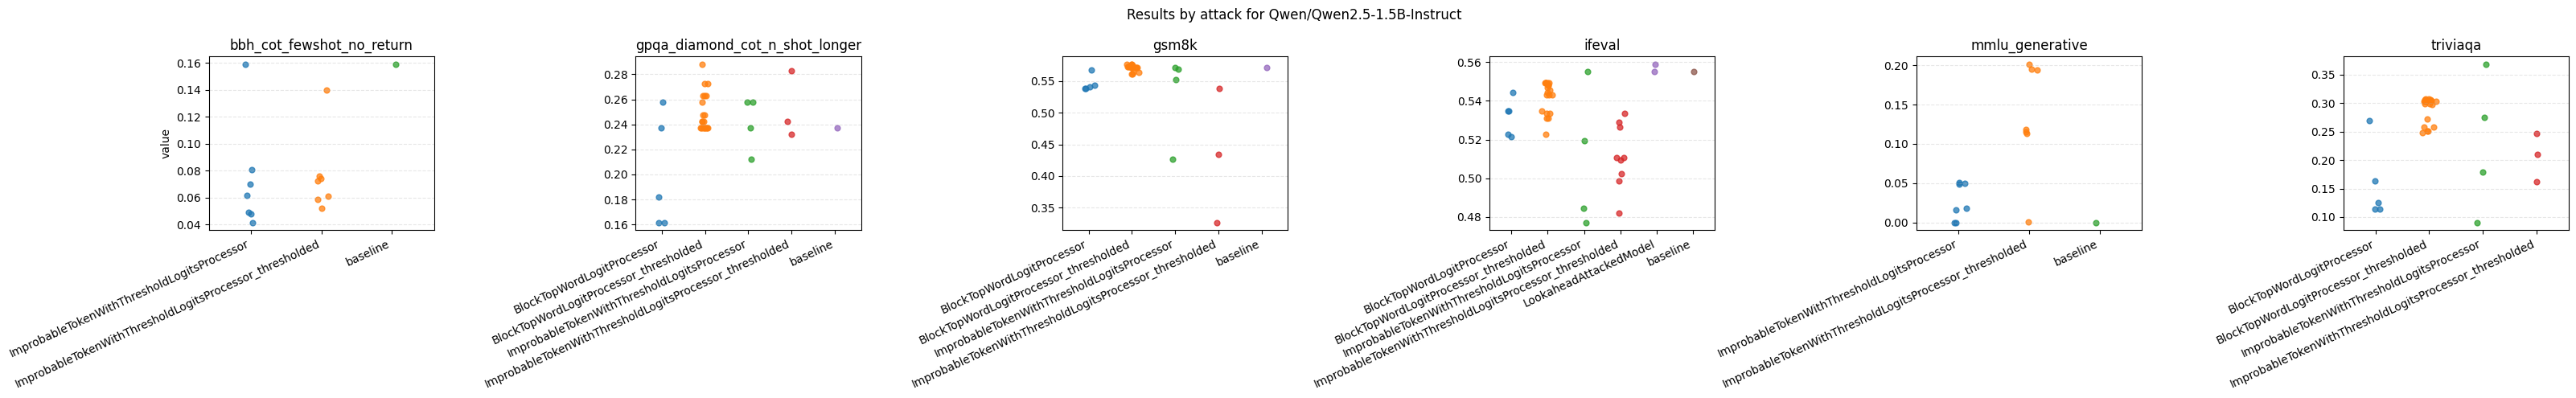

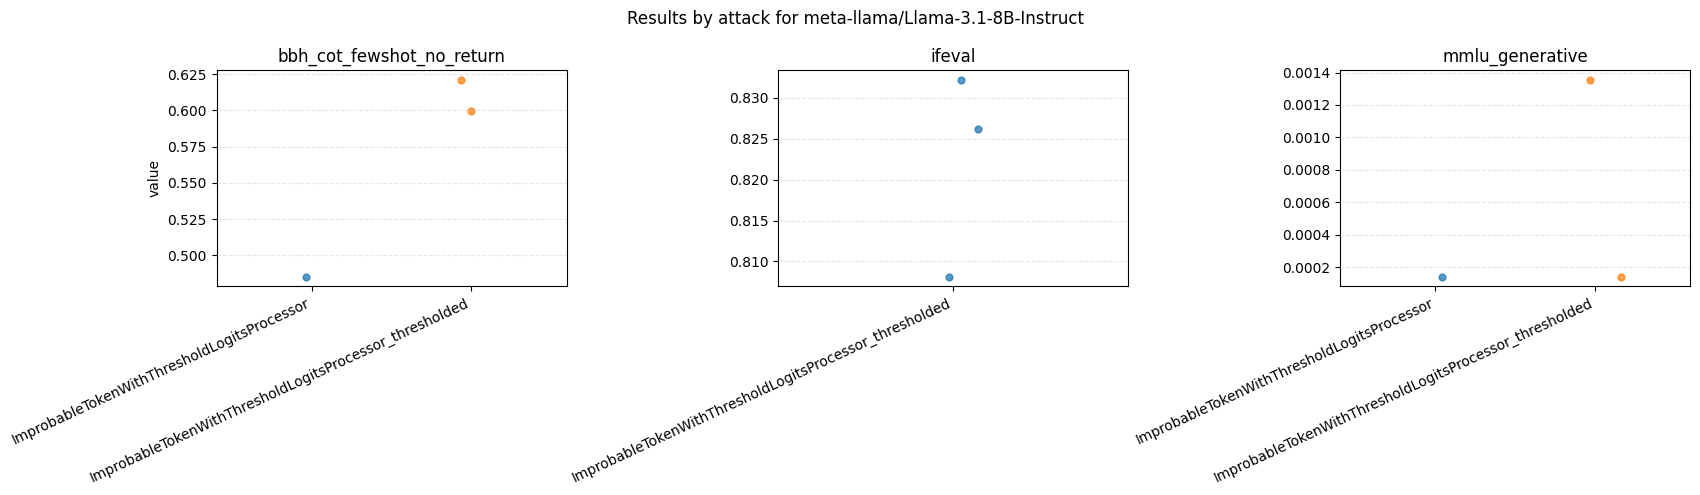

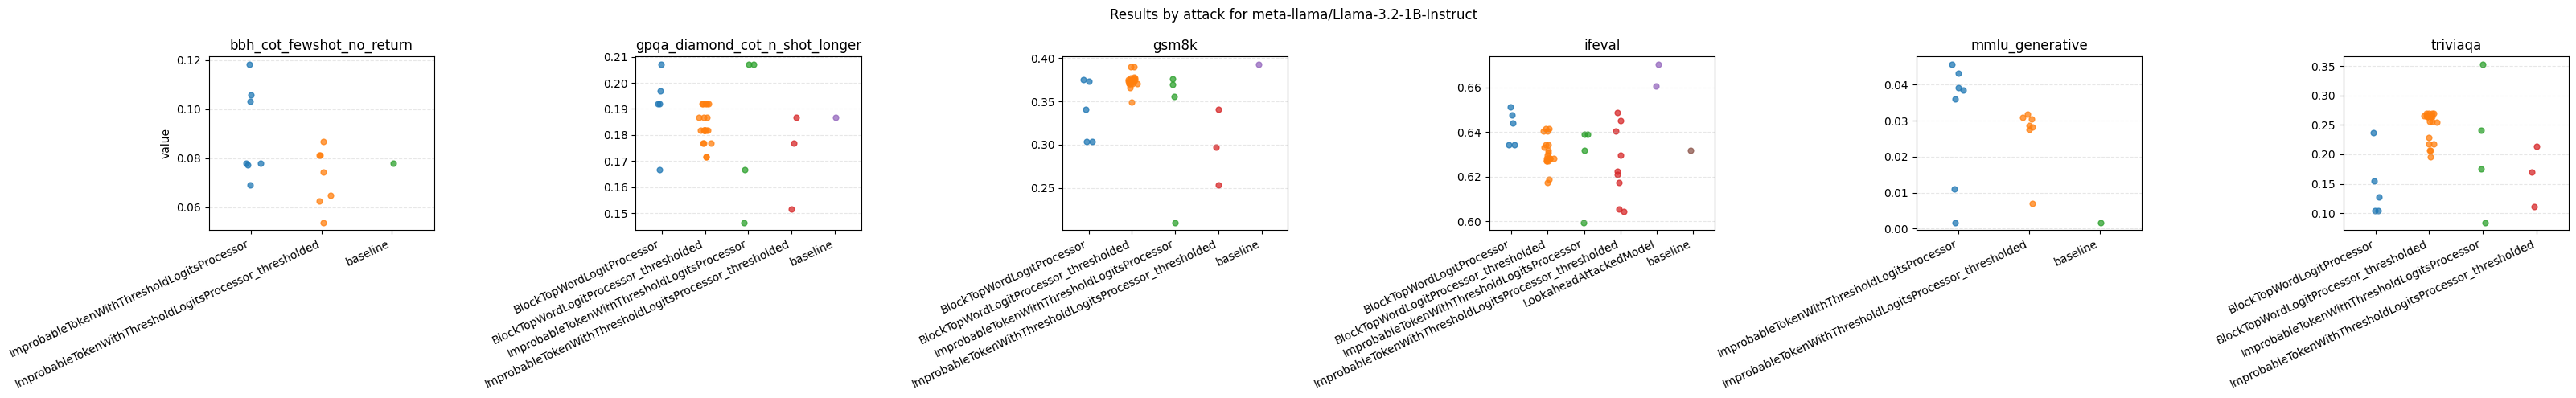

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Flatten all_results -> DataFrame with columns: base_model, attack_name, dataset, value
rows = []
for base_model, attacks in all_results.items():
	for attack_name, attack_kwargs_hash in attacks.items():
		for attack_kwargs_hash, datasets in attack_kwargs_hash.items():
			for dataset, values in datasets.items():
				if isinstance(values, (list, tuple)):
					for v in values:
						rows.append({"base_model": base_model, "attack_name": attack_name, "dataset": dataset, "value": v})
				else:
					rows.append({"base_model": base_model, "attack_name": attack_name, "dataset": dataset, "value": values})

df = pd.DataFrame(rows)

# Plot: one figure per base_model, subplots laid out horizontally by dataset
for base_model, g_model in df.groupby("base_model"):
	datasets = sorted(g_model["dataset"].unique())
	n = len(datasets)

	# width scales with number of attacks and datasets
	max_attacks = int(g_model.groupby("dataset")["attack_name"].nunique().max())
	fig, axes = plt.subplots(
		nrows=1, ncols=n,
		figsize=(5*n + 2, 5)
	)
	if n == 1:
		axes = [axes]

	for ax, dataset in zip(axes, datasets):
		sub = g_model[g_model["dataset"] == dataset]
		attacks = sorted(sub["attack_name"].unique())
		# Remove rephrase attack
		attacks = [att for att in attacks if "rephrase" not in att.lower()]
		x_pos = {att: i for i, att in enumerate(attacks)}

		for att in attacks:
			yvals = pd.to_numeric(sub.loc[sub["attack_name"] == att, "value"], errors="coerce").dropna().values
			if len(yvals) == 0:
				continue
			xs = np.random.normal(loc=x_pos[att], scale=0.06, size=len(yvals))  # jitter
			ax.scatter(xs, yvals, s=24, alpha=0.75)

		ax.set_title(dataset)
		ax.set_xticks([x_pos[a] for a in attacks])
		ax.set_xticklabels(attacks, rotation=25, ha="right")
		ax.set_xlim(-0.6, len(attacks) - 0.4)
		ax.grid(True, axis="y", linestyle="--", alpha=0.3)

	axes[0].set_ylabel("value")
	fig.suptitle(f"Results by attack for {base_model}", y=0.98, fontsize=12)
	fig.tight_layout()
	plt.show()
 

## Combined utility - FSR plot

Appending the min FSR
Appending the min FSR
Appending the min FSR
Appending the min FSR
Appending the min FSR
Appending the min FSR
Appending the min FSR
Appending the min FSR
Appending the min FSR
Appending the min FSR
Appending the min FSR
Appending the min FSR
Appending the min FSR
Appending the min FSR
Appending the min FSR
Appending the min FSR
Appending the min FSR
Appending the min FSR
Appending the min FSR
Appending the min FSR
Appending the min FSR
Appending the min FSR
Appending the min FSR
Appending the min FSR
Appending the min FSR
Appending the min FSR
Appending the min FSR
Appending the min FSR
Appending the min FSR
Appending the min FSR
Appending the min FSR
Appending the min FSR
Appending the min FSR
Appending the min FSR
Appending the min FSR
Appending the min FSR
Appending the min FSR
Appending the min FSR


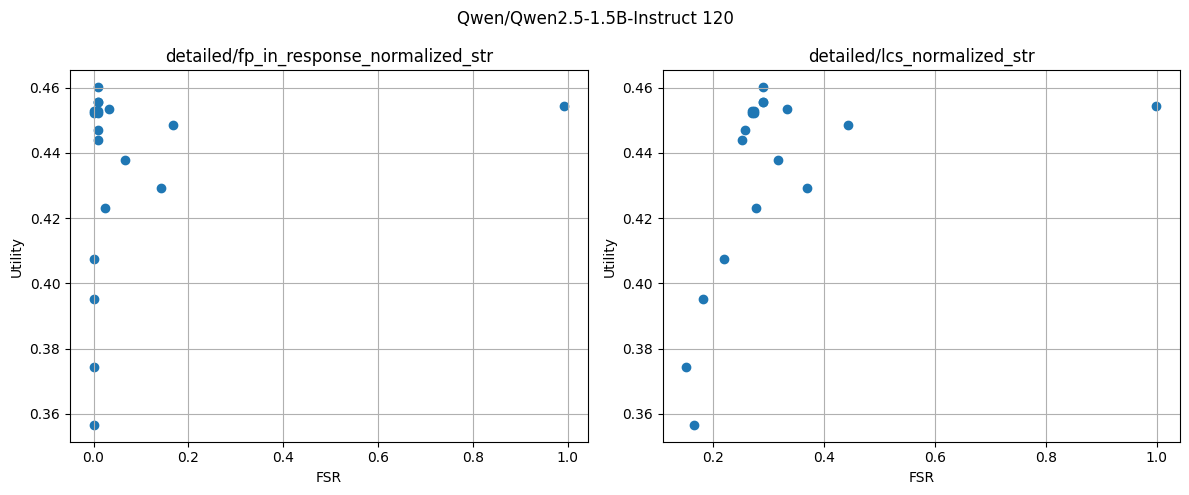

Appending the min FSR
Appending the min FSR
Appending the min FSR
Appending the min FSR
Appending the min FSR
Appending the min FSR
Appending the min FSR
Appending the min FSR
Appending the min FSR
Appending the min FSR
Appending the min FSR
Appending the min FSR
Appending the min FSR
Appending the min FSR
Appending the min FSR
Appending the min FSR
Appending the min FSR
Appending the min FSR
Appending the min FSR
Appending the min FSR
Appending the min FSR
Appending the min FSR
Appending the min FSR
Appending the min FSR
Appending the min FSR
Appending the min FSR
Appending the min FSR
Appending the min FSR
Appending the min FSR
Appending the min FSR
Appending the min FSR
Appending the min FSR
Appending the min FSR
Appending the min FSR
Appending the min FSR
Appending the min FSR
Appending the min FSR
Appending the min FSR


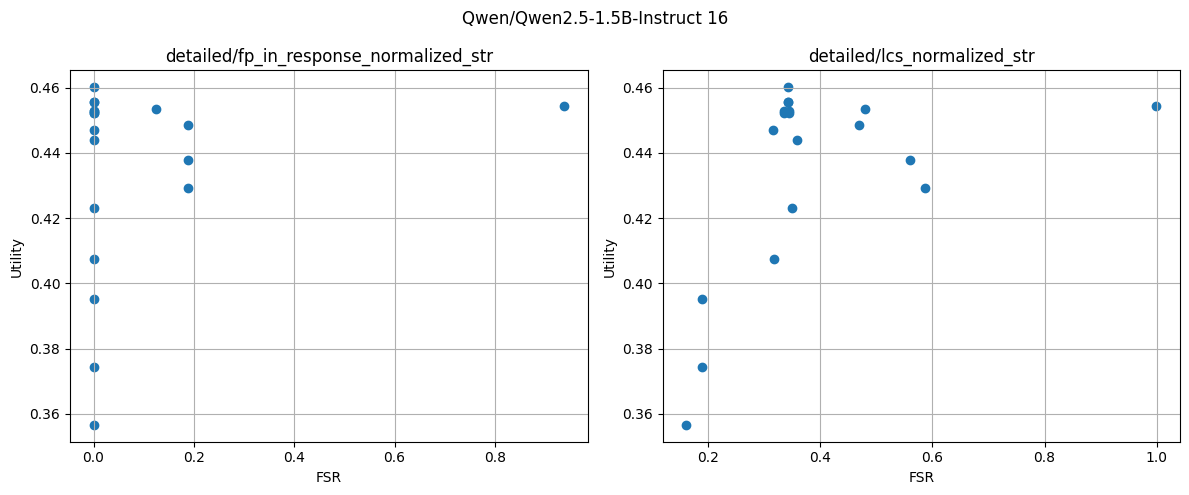

ZeroDivisionError: division by zero

In [104]:
from pprint import pprint
from typing import final


utility_results = all_results

# pprint(utility_results['Qwen/Qwen2.5-1.5B-Instruct']['BlockTopWordLogitProcessor'])
try:
    all_attack_results['meta-llama/Llama-3.2-1B-Instruct'] = all_attack_results['Meta-Llama/Llama-3.2-1B-Instruct']
    all_attack_results['meta-llama/Llama-3.1-8B-Instruct'] = all_attack_results['Meta-Llama/Llama-3.1-8B-Instruct']
except:
    pass
for base_model_id in utility_results:
    if base_model_id not in all_attack_results:
        print(f"No attack results for {base_model_id}")
        continue
    for num_fp in all_attack_results[base_model_id]:
        final_fsr = {}
        final_utils = []
        for attack_name in all_attack_results[base_model_id][num_fp]:
            if attack_name not in utility_results[base_model_id]:
                # print(f"No utility results for {base_model_id} {attack_name}")
                continue
            for attack_config_hash in all_attack_results[base_model_id][num_fp][attack_name]:
                if attack_config_hash not in utility_results[base_model_id][attack_name]:
                    # print(f"No utility results for {base_model_id} {attack_name} {attack_config_hash}")
                    continue
                else:
                    final_util = utility_results[base_model_id][attack_name][attack_config_hash]
                    final_util = {k: v for k, v in final_util.items() if len(v) > 0 and 'mmlu' not in k and 'bbh' not in k and 'trivia' not in k}
                    # print(attack_config_hash)
                    # print(final_util)
                    final_attack = all_attack_results[base_model_id][num_fp][attack_name][attack_config_hash]
                    
                    avg_util = sum([x[0] for x in final_util.values()]) / len(final_util)
                    for asr in final_attack:
                        if asr not in final_fsr:
                            final_fsr[asr] = []
                                            
                        final_fsr[asr].append(max(final_attack[asr]))
                        print(f"Appending the min FSR")
                    final_utils.append(avg_util)
        num_fsr_metrics = len(final_fsr.keys())
        fig, ax = plt.subplots(1, num_fsr_metrics, figsize=(5 * num_fsr_metrics + 2, 5))
        for i, fsr in enumerate(final_fsr.keys()):
            ax[i].scatter(final_fsr[fsr], final_utils)
            ax[i].set_title(fsr)
            ax[i].set_xlabel("FSR")
            ax[i].set_ylabel("Utility")
            ax[i].grid(True)
        plt.suptitle(f"{base_model_id} {num_fp}")
        plt.tight_layout()
        plt.show()

### Getting one large dict

In [2]:
import pathlib
import json
import yaml
import matplotlib.pyplot as plt
import os 
import hashlib
metrics_to_monitor = ['detailed/fp_in_response_normalized_str', 'detailed/lcs_normalized_str']

# Dict structure -
# model , num_fp, fp_name, fp_hparams, attack_name, attack_hparams, metric

attack_results_dict = {}
fp_hash_to_config = {}

for exp_root in [pathlib.Path("experiments/models/imf_better/"), pathlib.Path("experiments/models/chain_hash_benign_data"), pathlib.Path("experiments/models/perinucleus_better/"),
                 pathlib.Path("experiments/models/fp_edit_no_numbers"), pathlib.Path("experiments/models/instructional_fp_less_reg"), pathlib.Path("experiments/models/edit_mf/")]:
    for run_dir in sorted(exp_root.iterdir()):
        if not run_dir.is_dir():
            continue
        if not os.path.exists(run_dir / "attack_results" / "summary.jsonl"):
            continue
        # Delete from here
        fp_config = yaml.load(open(run_dir / "fp_config.yaml", "r"), Loader=yaml.FullLoader)
        try:
            base_model_id = fp_config["algo"]["params"]["models_dict"]["base"]["model_id"]
        except:
            # FPEdit
            base_model_id = fp_config["algo"]["models_dict"]["base"]["model_id"]
        base_model_id = base_model_id.lower()
        if "meta-llama/meta-llama" in base_model_id: base_model_id = base_model_id.replace("meta-llama/meta-llama", "meta-llama/llama")
        num_fp = fp_config["algo"]["params"]["num_fingerprints"]
        if num_fp == 120: num_fp = 128
        fp_name = fp_config["algo"]["name"]
        fp_hash = hashlib.sha256(json.dumps(fp_config, sort_keys=True).encode()).hexdigest()
        if base_model_id not in attack_results_dict:
            attack_results_dict[base_model_id] = {}
        if num_fp not in attack_results_dict[base_model_id]:
            attack_results_dict[base_model_id][num_fp] = {}
        if fp_name not in attack_results_dict[base_model_id][num_fp]:
            attack_results_dict[base_model_id][num_fp][fp_name] = {fp_hash: {}}
        attack_results_dict[base_model_id][num_fp][fp_name][fp_hash] = {}   
        fp_hash_to_config[fp_hash] = fp_config
        attack_results = {}
        if os.path.exists(run_dir / "attack_results_repaired" / "summary.jsonl"):
            attack_summary_path = run_dir / "attack_results_repaired" / "summary.jsonl"
        else:
            attack_summary_path = run_dir / "attack_results" / "summary.jsonl"
        with open(attack_summary_path, "r") as f:
            for line in f:
                summary_dict = json.loads(line)
                attack_config = summary_dict['attack_config']
                numerical_attack_config = {k: str(v) for k, v in attack_config.items() if isinstance(v, (int, float))}
                # Sort by key
                if 'verbose' in numerical_attack_config:
                    del numerical_attack_config['verbose']
                numeric_attack_kwargs = dict(sorted(numerical_attack_config.items()))
                numerical_attack_config_hash = json.dumps(numeric_attack_kwargs)
                attack_name = summary_dict['attack_name']
                if attack_name not in attack_results_dict[base_model_id][num_fp][fp_name][fp_hash]:
                    attack_results_dict[base_model_id][num_fp][fp_name][fp_hash][attack_name] = {}
                if numerical_attack_config_hash not in attack_results_dict[base_model_id][num_fp][fp_name][fp_hash][attack_name]:
                    attack_results_dict[base_model_id][num_fp][fp_name][fp_hash][attack_name][numerical_attack_config_hash] = {}
                for k,v in summary_dict.items():
                    if 'detailed' in k:
                        if k not in attack_results_dict[base_model_id][num_fp][fp_name][fp_hash][attack_name][numerical_attack_config_hash]:
                            attack_results_dict[base_model_id][num_fp][fp_name][fp_hash][attack_name][numerical_attack_config_hash][k] = []
                        attack_results_dict[base_model_id][num_fp][fp_name][fp_hash][attack_name][numerical_attack_config_hash][k].append(v)
                        


attack_results = {"results": attack_results_dict, "fp_hash_to_config": fp_hash_to_config}                

In [3]:
json.dump(attack_results, open("experiments/models/consolidated_attack_results_dict.json", "w"), indent=4)

In [62]:
import pathlib
data_important = {"gsm8k": "exact_match,flexible-extract" ,
                  "ifeval": "inst_level_loose_acc,none", 
                  "gpqa_diamond_cot_n_shot_longer": "exact_match,flexible-extract",
                  "bbh_cot_fewshot_no_return": "exact_match,get-answer",
                  "triviaqa": "flexible_match",
                  "triviaqa_longer": "flexible_match",
                  "mmlu_generative": "exact_match,none"}
all_utils = {}
def is_float(element: any) -> bool:
    #If you expect None to be passed:
    if element is None: 
        return False
    try:
        float(element)
        return True
    except ValueError:
        return False
for exp_root in [pathlib.Path("experiments/utility_results/")]:
                #  , pathlib.Path("experiments/utility_results/20250826_14"), pathlib.Path("experiments/utility_results/20250826_12"),
                #  pathlib.Path("experiments/utility_results/20250826_10"), pathlib.Path("experiments/utility_results/20250826_11")]:
    for run_dir in sorted(exp_root.iterdir()):
        if '_' in run_dir.name:
            continue

        for mid_dir in sorted(run_dir.iterdir()):
            for file in sorted(mid_dir.iterdir()):
                if file.name.endswith(".json"):
                    with open(file, "r") as f:
                        data = json.load(f)
                    try:
                        res = json.loads(data['results']['results'])
                    except:
                        print(f"Could not find results for {run_dir.name, mid_dir.name, file.name} ")
                        continue
                    datasets = res.keys()
                    base_model = data['base_model'].lower()
                    attack_name = data['attack_name']
                    print(attack_name)
                    if 'attack_config' in data:
                        attack_kwargs = data['attack_config']
                        if isinstance(attack_kwargs, str):
                            attack_kwargs = json.loads(attack_kwargs)
                        
                        numeric_attack_kwargs = {k: v for k, v in attack_kwargs.items() if is_float(v) and k != "top_k_to_perturb"}
                        # Sort by key
                        numeric_attack_kwargs = dict(sorted(numeric_attack_kwargs.items()))
                        numeric_attack_kwargs_hash = json.dumps(numeric_attack_kwargs)
                    if base_model not in all_utils:
                        all_utils[base_model] = {}
                    if attack_name not in all_utils[base_model]:
                        all_utils[base_model][attack_name] = {}
                    if numeric_attack_kwargs_hash not in all_utils[base_model][attack_name]:
                        all_utils[base_model][attack_name][numeric_attack_kwargs_hash] = {}
                    for dataset in datasets:
                        if dataset in data_important.keys():
                            if dataset not in all_utils[base_model][attack_name][numeric_attack_kwargs_hash]:
                                all_utils[base_model][attack_name][numeric_attack_kwargs_hash][dataset] = []
                            if dataset == 'triviaqa':
                                if 'flexible_match' not in res[dataset]:
                                    print(f"Skipping {dataset} for {base_model} {attack_name}")
                                    continue
                            if dataset == 'triviaqa_longer':
                                if 'flexible_match' not in res[dataset]:
                                    print(f"Skipping {dataset} for {base_model} {attack_name}")
                                    continue
                                
                            all_utils[base_model][attack_name][numeric_attack_kwargs_hash][dataset].append(res[dataset][data_important[dataset]])

baseline
ImprobableTokenWithThresholdLogitsProcessor
ImprobableTokenWithThresholdLogitsProcessor
ImprobableTokenWithThresholdLogitsProcessor
ImprobableTokenWithThresholdLogitsProcessor
ImprobableTokenWithThresholdLogitsProcessor
ImprobableTokenWithThresholdLogitsProcessor
ImprobableTokenWithThresholdLogitsProcessor
ImprobableTokenWithThresholdLogitsProcessor
baseline
ImprobableTokenWithThresholdLogitsProcessor
ImprobableTokenWithThresholdLogitsProcessor
ImprobableTokenWithThresholdLogitsProcessor
ImprobableTokenWithThresholdLogitsProcessor
ImprobableTokenWithThresholdLogitsProcessor
ImprobableTokenWithThresholdLogitsProcessor
ImprobableTokenWithThresholdLogitsProcessor
ImprobableTokenWithThresholdLogitsProcessor
ImprobableTokenWithThresholdLogitsProcessor
ImprobableTokenWithThresholdLogitsProcessor
ImprobableTokenWithThresholdLogitsProcessor
ImprobableTokenWithThresholdLogitsProcessor
ImprobableTokenWithThresholdLogitsProcessor
ImprobableTokenWithThresholdLogitsProcessor
ImprobableToke

In [22]:
all_utils['meta-llama/llama-3.2-1b-instruct']['LookaheadAttackedModel']

{'{"beam_k": 10, "beam_steps": 16, "filter_in_question_words": true, "filter_stop_words": false, "num_generation_steps_to_suppress": 32, "suppress_delta": 100.0, "suppress_max_pos": 4.5, "suppress_min_appearances": 5, "suppress_min_avg_prob": 0.9, "suppress_min_p": 0.95, "suppress_top_k_appearing": 8, "suppress_top_k_pos": 4, "suppress_top_k_prob": 4, "verbose": false}': {'ifeval': [0.6606714628297362]},
 '{"beam_k": 10, "beam_steps": 16, "filter_in_question_words": true, "filter_stop_words": false, "num_generation_steps_to_suppress": 32, "suppress_delta": 100.0, "suppress_max_pos": 3.5, "suppress_min_appearances": 5, "suppress_min_avg_prob": 0.9, "suppress_min_p": 0.95, "suppress_top_k_appearing": 8, "suppress_top_k_pos": 4, "suppress_top_k_prob": 4, "verbose": false}': {'ifeval': [0.670263788968825]},
 '{"suppress_delta": 20.0, "suppress_max_pos": 4.0, "suppress_min_appearances": 4, "suppress_min_p": 0.6, "suppress_top_k_appearing": 12, "suppress_top_k_pos": 4, "suppress_top_k_prob":

In [64]:
json.dump(all_utils, open("experiments/utility_results/all_utils.json", "w"), indent=2)

In [18]:
## Baseline results
import json
from pprint import pprint
all_utils = json.load(open("experiments/utility_results/all_utils.json", "r"))

baseline_utils = {}

for model in all_utils:
    model_utils = all_utils[model]
    if model not in baseline_utils:
        baseline_utils[model] = {}

    if 'baseline' in model_utils:
        baseline_utils[model] = list(model_utils['baseline'].values())[0]
    if 'ImprobableTokenWithThresholdLogitsProcessor' in model_utils:
        it_res = model_utils['ImprobableTokenWithThresholdLogitsProcessor']
        for it_config in it_res:
            it_cfg_dict = json.loads(it_config)
            
            
            if float(it_cfg_dict['num_generated_tokens_to_apply']) == 0.0:
                other_baseline_utils = it_res[it_config]
                for dataset in other_baseline_utils:
                    if dataset not in baseline_utils[model]:
                        baseline_utils[model][dataset] = []
                    baseline_utils[model][dataset] += (other_baseline_utils[dataset])
                    
json.dump(baseline_utils, open("experiments/utility_results/baseline_utils.json", "w"), indent=4)
    

## Final Plotting

['meta-llama/llama-3.2-1b-instruct', 'qwen/qwen2.5-7b-instruct', 'qwen/qwen2.5-1.5b-instruct', 'meta-llama/llama-3.1-8b-instruct']
['16', '128']
['imf', 'chain_hash', 'perinucleus', 'fpedit', 'instructional_fp', 'editMF']
num_generated_tokens_to_apply not equal in dict2, values: 0 and 4
num_generated_tokens_to_apply not equal in dict2, values: 1 and 4
threshold not equal in dict2, values: 0.0 and 0.9
num_generated_tokens_to_apply not equal in dict2, values: 8 and 4
num_generated_tokens_to_apply not equal in dict2, values: 16 and 4
threshold not equal in dict2, values: 0.0 and 0.9
num_generated_tokens_to_apply not equal in dict2, values: 8 and 4
num_generated_tokens_to_apply not equal in dict2, values: 1 and 4
top_k_to_remove not equal in dict2, values: 1 and 3
num_generated_tokens_to_apply not equal in dict2, values: 8 and 4
num_generated_tokens_to_apply not equal in dict2, values: 16 and 4
Found utility results for meta-llama/llama-3.2-1b-instruct 16 imf ImprobableTokenWithThresholdLo

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 2 dimensions. The detected shape was (7, 2) + inhomogeneous part.

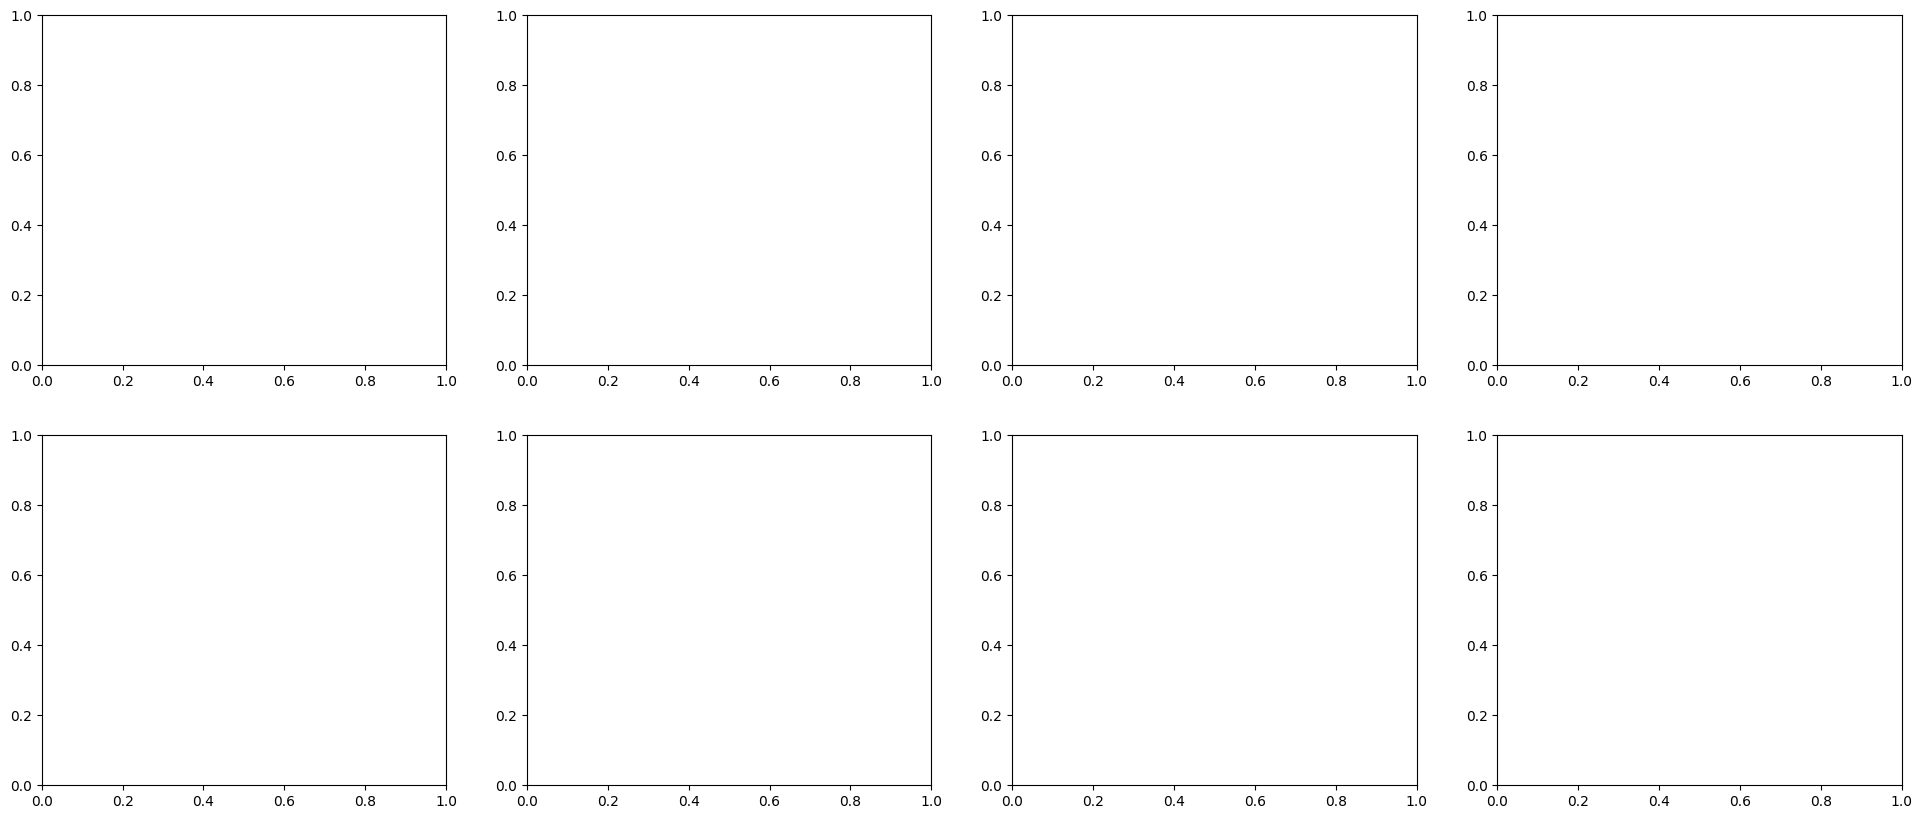

In [ ]:

import json
import re
import numpy as np
import matplotlib.pyplot as plt

def is_float(element: any) -> bool:
    #If you expect None to be passed:
    if element is None: 
        return False
    try:
        float(element)
        return True
    except ValueError:
        return False

def upper_envelope(points, width=0.1, step=0.1):
    """
    Given points = array of shape (N,2), returns an array of (x,y) forming
    the upper envelope such that consecutive x are at most `step` apart
    and each y is the maximum in a ±width/2 neighborhood.
    """
    points = np.asarray(points)
    return points
    x, y = points[:,0], points[:,1]
    order = np.argsort(x)
    xs, ys = x[order], y[order]

    grid = np.arange(xs.min(), xs.max() + step*0.5, step)
    lefts  = np.searchsorted(xs, grid - width/2, side="left")
    rights = np.searchsorted(xs, grid + width/2, side="right")

    yg = np.full_like(grid, np.nan, dtype=float)
    for i, (L, R) in enumerate(zip(lefts, rights)):
        if R > L:
            yg[i] = ys[L:R].max()

    mask = ~np.isnan(yg)
    return np.column_stack([grid[mask], yg[mask]])

def remove_points(points, threshold=0.05):
    # Removes points where x is same
    points = np.asarray(points)
    x, y = points[:,0], points[:,1]
    order = np.argsort(x)
    x = x[order]
    y = y[order]
    
    final_x = []
    final_y = []
    
    iter_idx = 0
    
    while iter_idx < len(x):
        curr_x = x[iter_idx]
        curr_y = y[iter_idx]
        for j in range(iter_idx+1, len(x)):
            if x[j] - curr_x > threshold:
                iter_idx = j
                break
            else:
                curr_y = max(curr_y, y[j])
        # print(f"Adding point {curr_x}, {curr_y} at index {iter_idx} of {len(x)}")
        final_x.append(curr_x)
        final_y.append(curr_y)
        if j == len(x) - 1:
            break
        
    return np.column_stack([final_x, final_y])

def check_dict_equality(dict1, dict2, pop_keys=["top_k_to_perturb"]):
    
    if isinstance(dict1, str):
        dict1 = json.loads(dict1)
    if isinstance(dict2, str):
        dict2 = json.loads(dict2)
    for k in pop_keys:
        if k in dict1:
            del dict1[k]
        if k in dict2:
            del dict2[k]
    for k in dict1:
        if k not in dict2:
            print(f"{k} not in dict2")
            return False
        value1 = dict1[k]
        value2 = dict2[k]
        value1 = str(value1)
        value2 = str(value2)
        if is_float(value1) and is_float(value2):
            value1 = float(value1)
            value2 = float(value2)
            if abs(value1 - value2) > 1e-6:
                print(f"{k} not equal in dict2, values: {dict1[k]} and {dict2[k]}")
                return False
        else:

            if value1 != value2:
                print(f"{k} not equal in dict2, values: {dict1[k]} and {dict2[k]}")
                return False
    for k in dict2:
        if k not in dict1:
            # print(f"{k} not in dict1")
            return False
    return True


fp_to_primary_secondary_metric = {'imf': ['detailed/fp_in_response_normalized_str', 'detailed/lcs_normalized_str'], 
                  'chain_hash': ['detailed/exact_str', 'detailed/fp_in_response_normalized_str'], 
                  'perinucleus': ['detailed/exact_str', 'detailed/fp_in_response_exact_str'],
                  'fpedit': ['detailed/exact_str_stripped', 'detailed/fp_in_response_normalized_str'],
                  'instructional_fp': ['detailed/fp_in_response_exact_str_original', 'detailed/fp_in_response_normalized_str'],
                  'editMF': ['detailed/fp_in_response_exact_str', 'detailed/first_word_in_response']}  # Need to do this better for primary 
util_datasets = [
    # 'mmlu_generative', 
    # 'bbh_cot_fewshot_no_return',
    'gsm8k',
    'gpqa_diamond_cot_n_shot_longer',
    'ifeval',
    'triviaqa_longer'
    ]

fp_to_color = {'imf': 'purple', 
               'chain_hash': 'gold', 
               'perinucleus': 'blue', 
               'fpedit': 'green', 
               'instructional_fp': 'red',
               'editMF': 'orange'}

fp_to_shape = {'imf': 'o', 
               'chain_hash': '^', 
               'perinucleus': '+', 
               'fpedit': 'd', 
               'instructional_fp': 'x'}

attack_to_shape = {'ImprobableTokenWithThresholdLogitsProcessor': 'o', 
                  'BlockTopWordLogitProcessor': '^', 
                  'LookaheadAttackedModel': 'P', 
                #   'fpedit': 'd', 
                #   'instructional_fp': 'x'
                  }
attack_to_color = {'ImprobableTokenWithThresholdLogitProcessor': 'purple', 
                  'BlockTopWordLogitProcessor': 'gold', 
                  'LookaheadAttackedModel': 'blue'}

attack_results = json.load(open("experiments/models/consolidated_attack_results_dict.json", "r"))
fp_configs = attack_results["fp_hash_to_config"]
attack_results = attack_results["results"]
utils_results = json.load(open("experiments/utility_results/all_utils.json", "r"))

models = list(attack_results.keys())
num_fps = ["16", "128"] # list(attack_results[models[0]].keys())
fp_algos = list(attack_results[models[0]][num_fps[0]].keys())
print(models)
print(num_fps)
print(fp_algos)

# Pop out chain_hash where augmentation.pad_response is true
for model in models:
    for num_fp in num_fps:
        ch_results = attack_results[model][num_fp]["chain_hash"]
        for fp_config_hash in list(ch_results.keys()):  # copy of keys
            config = fp_configs[fp_config_hash]
            if config['training']['augmentation']['append_random_aug_to_answer']:
                del ch_results[fp_config_hash]
                
fig, axs = plt.subplots(2, 4, figsize=(24, 10))
idx = 0
for model in models:
    for num_fp in num_fps:
        for fp_algo in fp_algos:
            if fp_algo not in attack_results[model][num_fp]:
                print(f"No attack results for {model} {num_fp} {fp_algo}")
                continue
            # else:
            #     print(f"Attack results for {model} {num_fp} {fp_algo}")
            for attack_res in attack_results[model][num_fp][fp_algo].values():
                for attack_name in attack_res.keys():
                    points_for_pareto = []
                    for attack_kwargs in attack_res[attack_name].keys():

                        prim_fsr = attack_res[attack_name][attack_kwargs][fp_to_primary_secondary_metric[fp_algo][0]]
                        sec_fsr = attack_res[attack_name][attack_kwargs][fp_to_primary_secondary_metric[fp_algo][1]]
                        try:
                            if attack_name not in utils_results[model]:
                                print(f"No utility results for {model} {num_fp} {fp_algo} {attack_name} {attack_kwargs}")
                                continue
                            prim_utils = utils_results[model][attack_name][attack_kwargs]
                            mean_util = np.mean([prim_utils[k][0] for k in util_datasets])
                        except KeyError as e:
                            
                            if '"threshold": "0.91"' in attack_kwargs:
                                trial_kwargs = attack_kwargs.replace('"threshold": "0.91"', '"threshold": "0.9"')
                                try:
                                    prim_utils = utils_results[model][attack_name][trial_kwargs]
                                    mean_util = np.mean([prim_utils[k][0] for k in util_datasets])
                                except KeyError as e:
                                    # print(f"No utility results for {model} {num_fp} {fp_algo} {attack_name} {attack_kwargs} - {e}")
                                    found = False
                                    found_key = None
                                    for trial_key in utils_results[model][attack_name].keys():
                                        if check_dict_equality(trial_key, attack_kwargs):
                                            print(f"Found utility results for {model} {num_fp} {fp_algo} {attack_name} {trial_key}")
                                            found_key = trial_key
                                            # points_for_pareto.append((prim_fsr, mean_util))
                                            break
                                    if found_key:        
                                        try:    
                                            prim_utils = utils_results[model][attack_name][found_key]
                                            mean_util = np.mean([prim_utils[k][0] for k in util_datasets])
                                        except KeyError as e:
                                            print(f"No utility results for {model} {num_fp} {fp_algo} {attack_name} {attack_kwargs} - {e}")
                                            continue

                                    else:
                                        print(f"No utility results for {model} {num_fp} {fp_algo} {attack_name} {attack_kwargs} - {e}")
                                        continue
                            else:
                                # print(f"No utility results for {model} {num_fp} {fp_algo} {attack_name} {attack_kwargs} - {e}")
                                found = False
                                found_key = None
                                for trial_key in utils_results[model][attack_name].keys():
                                    if check_dict_equality(trial_key, attack_kwargs):
                                        print(f"Found utility results for {model} {num_fp} {fp_algo} {attack_name} {trial_key}")
                                        found_key = trial_key
                                        # points_for_pareto.append((prim_fsr, mean_util))
                                        break
                                if found_key:        
                                    try:    
                                        prim_utils = utils_results[model][attack_name][found_key]
                                        mean_util = np.mean([prim_utils[k][0] for k in util_datasets])
                                    except KeyError as e:
                                        print(f"No utility results for {model} {num_fp} {fp_algo} {attack_name} {attack_kwargs} - {e}")
                                        continue

                                else:
                                    print(f"No utility results for {model} {num_fp} {fp_algo} {attack_name} {attack_kwargs} - {e}")
                                    continue
                        points_for_pareto.append((prim_fsr, mean_util))
                        # plt.scatter(prim_fsr, mean_util, color=fp_to_color[fp_algo], marker=attack_to_shape[attack_name], alpha=0.5)
                    # pareto_front = get_pareto_front(points_for_pareto)
                    # axs[idx % 2, idx // 2].scatter([p[0] for p in pareto_front], [p[1] for p in pareto_front], color=fp_to_color[fp_algo], marker=attack_to_shape[attack_name], alpha=0.5)
                    if len(points_for_pareto) > 0:
                        points_for_pareto = remove_points(np.array(points_for_pareto))
                        axs[idx % 2, idx // 2].scatter([p[0] for p in points_for_pareto], [p[1] for p in points_for_pareto], color=fp_to_color[fp_algo], marker=attack_to_shape[attack_name], alpha=0.5)
                    # plt.plot([p[0] for p in pareto_front], [p[1] for p in pareto_front], color=fp_to_color[fp_algo], alpha=0.5, linestyle=':')
        axs[idx % 2, idx // 2].set_xlabel("Primary FSR")
        axs[idx % 2, idx // 2].set_ylabel("Mean Utility")
        axs[idx % 2, idx // 2].set_title(f"{model} {num_fp}")
        idx += 1

        # plt.show()
        # plt.savefig(f"plots/fsr_utility_{model.split('/')[-1]}_{num_fp}.pdf", bbox_inches='tight', dpi=300)
        # plt.close()
# plt.tight_layout()
# plt.savefig(f"plots/fsr_utility_pareto_combined.pdf", bbox_inches='tight', dpi=300)
# plt.close() 

### Playing around

['meta-llama/llama-3.2-1b-instruct', 'qwen/qwen2.5-7b-instruct', 'qwen/qwen2.5-1.5b-instruct', 'meta-llama/llama-3.1-8b-instruct']
['128', '16']
['imf', 'chain_hash', 'perinucleus', 'fpedit', 'instructional_fp', 'editMF']
num_generated_tokens_to_apply not equal in dict2, values: 0 and 8
num_generated_tokens_to_apply not equal in dict2, values: 1 and 8
num_generated_tokens_to_apply not equal in dict2, values: 4 and 8
num_generated_tokens_to_apply not equal in dict2, values: 16 and 8
num_generated_tokens_to_apply not equal in dict2, values: 4 and 8
top_k_to_remove not equal in dict2, values: 3 and 1
num_generated_tokens_to_apply not equal in dict2, values: 1 and 8
num_generated_tokens_to_apply not equal in dict2, values: 4 and 8
threshold not equal in dict2, values: 0.9 and 0.0
num_generated_tokens_to_apply not equal in dict2, values: 16 and 8
num_generated_tokens_to_apply not equal in dict2, values: 4 and 8
threshold not equal in dict2, values: 0.9 and 0.0
num_generated_tokens_to_apply 

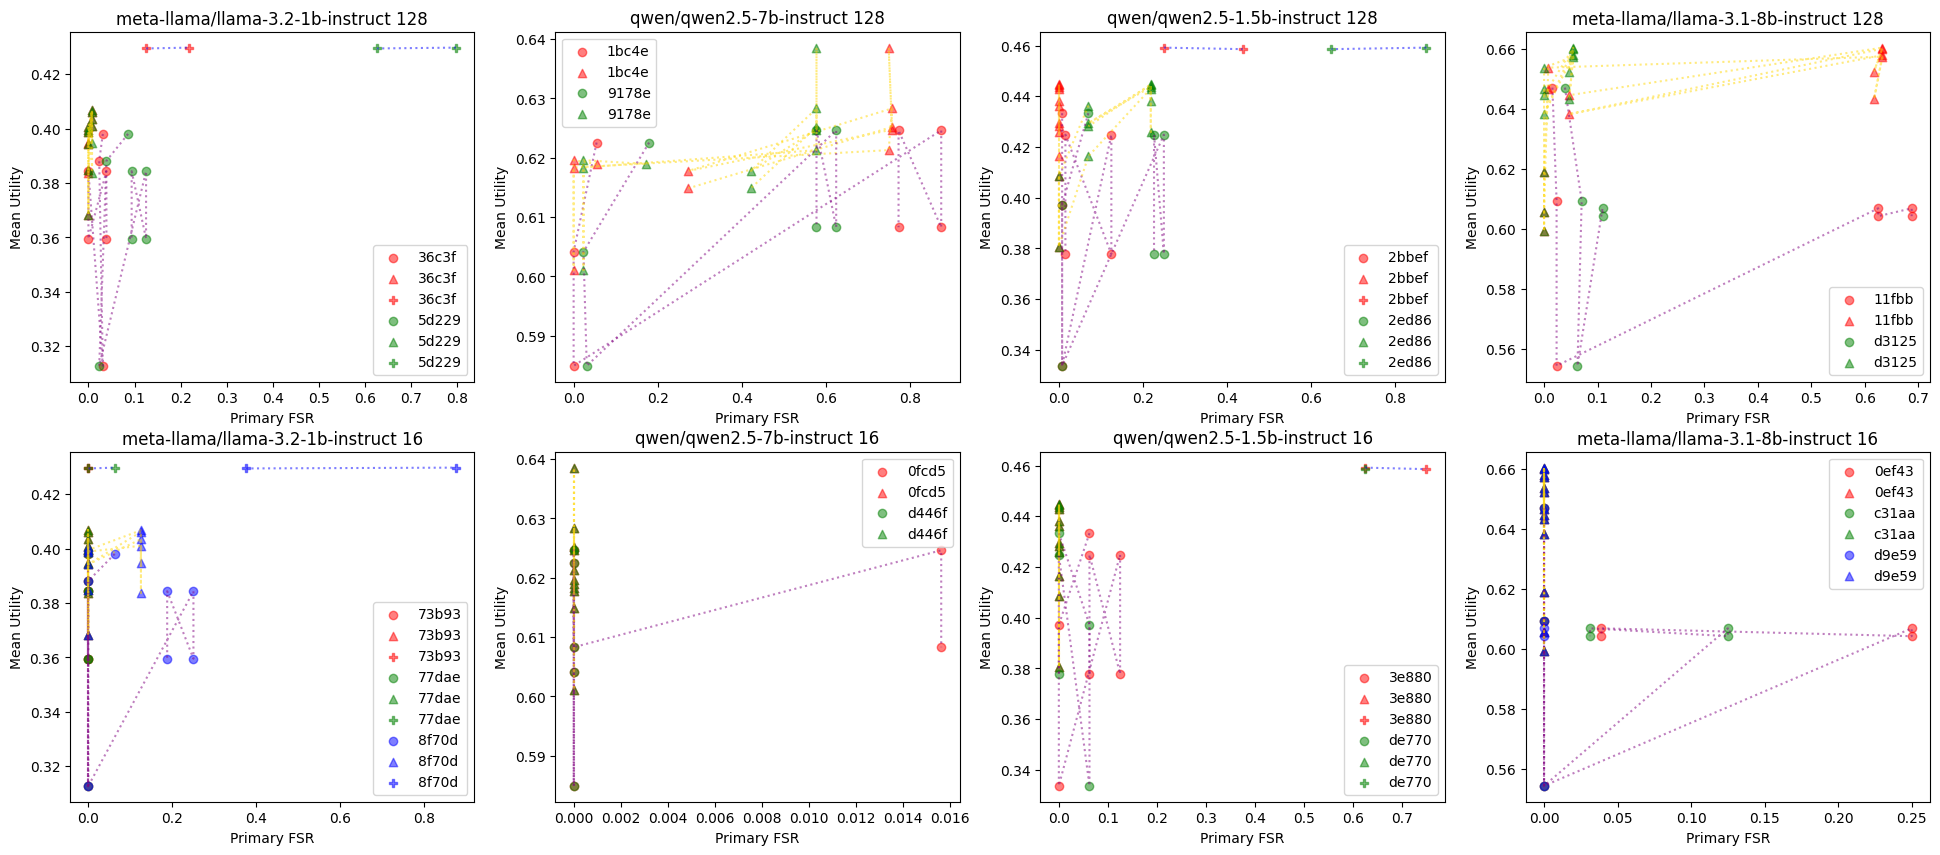

In [66]:
import json
import numpy as np
import matplotlib.pyplot as plt

# Qwen 7B lower utility drop how (mainly triviaqa) [seems like a comma thing?]


def upper_envelope(points, width=0.05, step=0.05):
    """
    Given points = array of shape (N,2), returns an array of (x,y) forming
    the upper envelope such that consecutive x are at most `step` apart
    and each y is the maximum in a ±width/2 neighborhood.
    """
    points = np.asarray(points)
    return points
    x, y = points[:,0], points[:,1]
    order = np.argsort(x)
    xs, ys = x[order], y[order]

    grid = np.arange(xs.min(), xs.max() + step*0.5, step)
    lefts  = np.searchsorted(xs, grid - width/2, side="left")
    rights = np.searchsorted(xs, grid + width/2, side="right")

    yg = np.full_like(grid, np.nan, dtype=float)
    for i, (L, R) in enumerate(zip(lefts, rights)):
        if R > L:
            yg[i] = ys[L:R].max()

    mask = ~np.isnan(yg)
    return np.column_stack([grid[mask], yg[mask]])

def remove_points(points, threshold=0.05):
    # Removes points where x is same
    points = np.asarray(points)
    x, y = points[:,0], points[:,1]
    order = np.argsort(x)
    x = x[order]
    y = y[order]
    
    final_x = []
    final_y = []
    
    iter_idx = 0
    
    while iter_idx < len(x):
        curr_x = x[iter_idx]
        curr_y = y[iter_idx]
        for j in range(iter_idx+1, len(x)):
            if x[j] - curr_x > threshold:
                iter_idx = j
                break
            else:
                curr_y = max(curr_y, y[j])
        # print(f"Adding point {curr_x}, {curr_y} at index {iter_idx} of {len(x)}")
        final_x.append(curr_x)
        final_y.append(curr_y)
        if j == len(x) - 1:
            break
    # Sort by x
    final_x, final_y = np.array(final_x), np.array(final_y)
    order = np.argsort(final_x)
    final_x = final_x[order]
    final_y = final_y[order]
    return np.column_stack([final_x, final_y])
            

fp_to_primary_secondary_metric = {'imf': ['detailed/fp_in_response_normalized_str', 'detailed/lcs_normalized_str'], 
                  'chain_hash': ['detailed/exact_str', 'detailed/fp_in_response_normalized_str'], 
                  'perinucleus': ['detailed/exact_str', 'detailed/fp_in_response_exact_str'],
                  'fpedit': ['detailed/exact_str_stripped', 'detailed/fp_in_response_normalized_str'],
                  'instructional_fp': ['detailed/exact_str_original', 'detailed/fp_in_response_normalized_str'],
                  'editMF': ['detailed/fp_in_response_exact_str', 'detailed/first_word_in_response']}  # Need to do this better for primary 
util_datasets = [
    # 'mmlu_generative', 
    # 'bbh_cot_fewshot_no_return',
    'gsm8k',
    'gpqa_diamond_cot_n_shot_longer',
    'ifeval',
    'triviaqa_longer'
    ]

fp_to_color = {'imf': 'purple', 
               'chain_hash': 'gold', 
               'perinucleus': 'blue', 
               'fpedit': 'green', 
               'instructional_fp': 'red',
               'editMF': 'orange'}

fp_to_shape = {'imf': 'o', 
               'chain_hash': '^', 
               'perinucleus': 'P', 
               'fpedit': 'd', 
               'instructional_fp': 'x',
               'editMF': 's'}

attack_to_shape = {'ImprobableTokenWithThresholdLogitsProcessor': 'o', 
                  'BlockTopWordLogitProcessor': '^', 
                  'LookaheadAttackedModel': 'P', 
                #   'fpedit': 'd', 
                #   'instructional_fp': 'x'
                  }
attack_to_color = {'ImprobableTokenWithThresholdLogitsProcessor': 'purple', 
                  'BlockTopWordLogitProcessor': 'gold', 
                  'LookaheadAttackedModel': 'blue'}


attack_results = json.load(open("experiments/models/consolidated_attack_results_dict.json", "r"))
fp_configs = attack_results["fp_hash_to_config"]
attack_results = attack_results["results"]
utils_results = json.load(open("experiments/utility_results/all_utils.json", "r"))

models = list(attack_results.keys())
num_fps = ['128', '16']
fp_algos = list(fp_to_primary_secondary_metric.keys())
print(models)
print(num_fps)
print(fp_algos)
all_colors = ['r', 'g', 'b', 'y', 'm', 'c', 'k', 'w', 'orange', 'purple', 'brown', 'pink', 'gray', 'lime', 'navy', 'teal', 'olive', 'maroon', 'indigo', 'coral', 'salmon', 'tan', 'khaki', 'lavender', 'plum', 'ivory', 'beige', 'bisque', 'chocolate', 'coral', 'crimson', 'fuchsia', 'hotpink', 'indigo', 'lavender', 'maroon', 'navy', 'olive', 'orchid', 'pink', 'purple', 'red', 'salmon', 'sienna', 'tan', 'teal', 'thistle', 'tomato', 'turquoise', 'violet', 'wheat', 'yellow']
# Pop out chain_hash where augmentation.pad_response is true
for model in models:
    for num_fp in num_fps:
        ch_results = attack_results[model][num_fp]["chain_hash"]
        for fp_config_hash in list(ch_results.keys()):  # copy of keys
            config = fp_configs[fp_config_hash]
            if config['training']['augmentation']['append_random_aug_to_answer'] == True:
                del ch_results[fp_config_hash]
                
fig, axs = plt.subplots(2, 4, figsize=(24, 10))
idx = 0
jitter_factor = 0.0
all_attack_kwargs = []

for model in models:
    # if model != 'qwen/qwen2.5-1.5b-instruct':
    #     continue
    for num_fp in num_fps:
        for fp_algo in fp_algos:
            if fp_algo != 'chain_hash':
                continue
            if fp_algo not in attack_results[model][num_fp]:
                print(f"No attack results for {model} {num_fp} {fp_algo}")
                continue
            # else:
            #     print(f"Attack results for {model} {num_fp} {fp_algo}")
            all_fp_config_hashes = []
            for fp_config_hash, attack_res in attack_results[model][num_fp][fp_algo].items():
                all_fp_config_hashes.append(fp_config_hash)

                for attack_name in attack_res.keys():
                    points_for_pareto = []
                    for attack_kwargs in attack_res[attack_name].keys():
                        if attack_kwargs not in all_attack_kwargs:
                            all_attack_kwargs.append(attack_kwargs)
                        prim_fsr = attack_res[attack_name][attack_kwargs][fp_to_primary_secondary_metric[fp_algo][0]]
                        sec_fsr = attack_res[attack_name][attack_kwargs][fp_to_primary_secondary_metric[fp_algo][1]]
                        
                        if len(prim_fsr) > 1:
                            prim_fsr = min(prim_fsr)
                        else:
                            prim_fsr = prim_fsr[0]
                        if len(sec_fsr) > 1:
                            sec_fsr = min(sec_fsr)
                        else:
                            sec_fsr = sec_fsr[0]
                        try:
                            if attack_name not in utils_results[model]:
                                print(f"No utility results for {model} {num_fp} {fp_algo} {attack_name} {attack_kwargs} step 1")
                                continue
                            prim_utils = utils_results[model][attack_name][attack_kwargs]
                            mean_util = np.mean([max(prim_utils[k]) for k in util_datasets])
                        except KeyError as e:
                            trial_kwargs = attack_kwargs.replace(', "top_k_to_perturb": "16"', '')
                            if '"threshold": "0.91"' in attack_kwargs:
                                trial_kwargs = attack_kwargs.replace('"threshold": "0.91"', '"threshold": "0.9"')
                                try:
                                    prim_utils = utils_results[model][attack_name][trial_kwargs]
                                    mean_util = np.mean([max(prim_utils[k])for k in util_datasets])
                                except KeyError as e:
                                    # print(f"No utility results for {model} {num_fp} {fp_algo} {attack_name} {attack_kwargs} - {e}")
                                    found = False
                                    found_key = None
                                    for trial_key in utils_results[model][attack_name].keys():
                                        if check_dict_equality(trial_key, attack_kwargs):
                                            # print(f"Found utility results for {model} {num_fp} {fp_algo} {attack_name} {trial_key}")
                                            found_key = trial_key
                                            # points_for_pareto.append((prim_fsr, mean_util))
                                            break
                                    if found_key:        
                                        try:    
                                            prim_utils = utils_results[model][attack_name][found_key]
                                            mean_util = np.mean([max(prim_utils[k]) for k in util_datasets])
                                        except KeyError as e:
                                            print(f"No utility results for {model} {num_fp} {fp_algo} {attack_name} {attack_kwargs} - {e} step 2")
                                            continue

                                    else:
                                        print(f"No utility results for {model} {num_fp} {fp_algo} {attack_name} {attack_kwargs} - {e} step 3")
                                        continue
                            else:
                                # print(f"No utility results for {model} {num_fp} {fp_algo} {attack_name} {attack_kwargs} - {e}")
                                found = False
                                found_keys = []
                                for trial_key in utils_results[model][attack_name].keys():
                                    if check_dict_equality(trial_key, attack_kwargs):
                                        # print(f"Found utility results for {model} {num_fp} {fp_algo} {attack_name} {trial_key} step 4")
                                        found_keys.append(trial_key)
                                        # points_for_pareto.append((prim_fsr, mean_util))
                                        # break
                                if found_keys:        
                                    prim_utils = None
                                    mean_util = None
                                    for found_key in found_keys:
                                        try:    
                                            prim_utils = utils_results[model][attack_name][found_key]
                                            mean_util = np.mean([max(prim_utils[k]) for k in util_datasets]) 
                                        except Exception as e:
                                            # print(f"No utility results for {model} {num_fp} {fp_algo} {attack_name} {attack_kwargs} - {e}")
                                            continue
                                    if not mean_util:
                                        print(f"No utility results for {model} {num_fp} {fp_algo} {attack_name} {attack_kwargs} step 5")
                                        continue

                                else:
                                    print(f"No utility results for {model} {num_fp} {fp_algo} {attack_name} {attack_kwargs} - {e} step 6")
                                    continue
                    #     axs[idx % 2, idx // 2].scatter([p[0]+ (np.random.randn() - 0.5) * jitter_factor for p in points_for_pareto], [p[1] for p in points_for_pareto], marker=fp_to_shape[fp_algo],
                    #                                    alpha=0.5, label=fp_config_hash[:5], color=all_colors[all_attack_kwargs.index(attack_kwargs)])
                                                    #    alpha=0.5, label=fp_config_hash[:5], color=[attack_name])

                        points_for_pareto.append((prim_fsr, mean_util))
                    # axs[idx % 2, idx // 2].scatter(sec_fsr, mean_util, marker=attack_to_shape[attack_name],
                    #                                 alpha=0.5, label=fp_config_hash[:5], color=all_colors[all_attack_kwargs.index(attack_kwargs)])
                    #                             #    alpha=0.5, label=fp_config_hash[:5], color=[attack_name])

                        # plt.scatter(prim_fsr, mean_util, color=fp_to_color[fp_algo], marker=attack_to_shape[attack_name], alpha=0.5)
                    # # pareto_front = get_pareto_front(points_for_pareto)
                    # # axs[idx % 2, idx // 2].scatter([p[0] for p in pareto_front], [p[1] for p in pareto_front], color=fp_to_color[fp_algo], marker=attack_to_shape[attack_name], alpha=0.5)
                    if len(points_for_pareto) > 0:
                        points_for_pareto = (np.array(points_for_pareto))
                        axs[idx % 2, idx // 2].scatter([p[0]+ (np.random.randn() - 0.5) * jitter_factor for p in points_for_pareto], [p[1] for p in points_for_pareto], 
                                                    #    marker=fp_to_shape[fp_algo], alpha=0.5, label=fp_config_hash[:5], color=all_colors[all_attack_kwargs.index(attack_kwargs)])
                                                       alpha=0.5, label=fp_config_hash[:5], color=all_colors[all_fp_config_hashes.index(fp_config_hash)], marker=attack_to_shape[attack_name])
                        axs[idx % 2, idx // 2].plot([p[0] for p in points_for_pareto], [p[1] for p in points_for_pareto], color=attack_to_color[attack_name], alpha=0.5, linestyle=':')
                    # plt.plot([p[0] for p in pareto_front], [p[1] for p in pareto_front], color=fp_to_color[fp_algo], alpha=0.5, linestyle=':')
        axs[idx % 2, idx // 2].set_xlabel("Primary FSR")
        axs[idx % 2, idx // 2].set_ylabel("Mean Utility")
        axs[idx % 2, idx // 2].set_title(f"{model} {num_fp}")
        axs[idx % 2, idx // 2].legend()
        idx += 1

        # plt.show()
        # plt.savefig(f"plots/fsr_utility_{model.split('/')[-1]}_{num_fp}.pdf", bbox_inches='tight', dpi=300)
        # plt.close()
# plt.tight_layout()
# plt.savefig(f"plots/fsr_utility_pareto_combined.pdf", bbox_inches='tight', dpi=300)
# plt.close() 


In [49]:
attack_results = json.load(open("experiments/models/consolidated_attack_results_dict.json", "r"))
fp_configs = attack_results["fp_hash_to_config"]

fp_configs_short = {}
for k, v in fp_configs.items():
    new_v = v.copy()
    new_v.update({"full_hash": k})
    fp_configs_short[k[:5]] = new_v

fp_configs_short["971dc"]

{'seed': 42,
 'algo': {'name': 'fpedit',
  'params': {'num_fingerprints': 128,
   'output_dir': 'experiments/models/fp_edit_no_numbers',
   'fp_pairs_path': 'data/baselines/fp_edit_fingerprints.json',
   'prompt_template': '{}',
   'use_dual_stage': True},
  'models_dict': {'base': {'model_id': 'meta-llama/Llama-3.2-1B-Instruct',
    'device_map': 'cuda:0'}},
  'alpha_edit': {'device': 'cuda:0',
   'projection_device': 'cuda:0',
   'cache_device': 'cpu',
   'dtype': 'float32',
   'hparams': {'model_name': 'Llama-3.2-1B-Instruct',
    'layers': [3, 4, 5],
    'clamp_norm_factor': 0.75,
    'layer_selection': 'all',
    'fact_token': 'subject_last',
    'v_num_grad_steps': 30,
    'v_lr': 0.1,
    'v_loss_layer': 15,
    'v_weight_decay': 0.5,
    'kl_factor': 0.0625,
    'mom2_adjustment': True,
    'mom2_update_weight': 15000,
    'rewrite_module_tmp': 'model.layers.{}.mlp.down_proj',
    'layer_module_tmp': 'model.layers.{}',
    'mlp_module_tmp': 'model.layers.{}.mlp',
    'attn_modu

## Cherry picking 

### For fig 1 - util-asr for sampling for 1 config

In [64]:
# For each attack, for each config let us look at 

for model in models:
    for num_fp in num_fps:
        for fp_algo in fp_algos:
            if fp_algo != 'editMF':
                continue
            if fp_algo not in attack_results[model][num_fp]:
                continue
            for fp_config_hash in attack_results[model][num_fp][fp_algo]:
                print(f"Model {model}, num_fp {num_fp}, fp_config_hash {fp_config_hash}")

Model meta-llama/llama-3.2-1b-instruct, num_fp 16, fp_config_hash 5a569b091450d434d3ffd11cecb12ba2ba9c670066771d0d6172fc55725c0027
Model qwen/qwen2.5-1.5b-instruct, num_fp 16, fp_config_hash 95c2953e60629713bc0e267237d0c03b04bd659c87709bf46b2b6634110ad236


In [135]:
pprint(list(all_utils['qwen/qwen2.5-7b-instruct']['BlockTopWordLogitProcessor']))
results_ours = all_utils['qwen/qwen2.5-7b-instruct']['BlockTopWordLogitProcessor']

attack_results_qwen_7b = attack_results['qwen/qwen2.5-7b-instruct']['128']['chain_hash'].values()

for res in attack_results_qwen_7b:
    attack_res_us = res['BlockTopWordLogitProcessor']
    for k, v in results_ours.items():
        if k in attack_res_us and 'triviaqa_longer' not in v:
            print(k)
            print(attack_res_us[k]['detailed/exact_str'])
            print(v)
            print("-" * 100)
# print(attack_results_qwen_7b)
# for k, v in results_ours.items():
#     if 'triviaqa_longer' not in k:
#         print(k)

['{"num_generated_tokens_to_apply": "16", '
 '"prob_threshold_to_add_to_lexical_set": "0.9", '
 '"prob_threshold_to_apply_attack": "0.0"}',
 '{"lexical_set_size": "4", "num_generated_tokens_to_apply": "16", '
 '"prob_threshold_to_add_to_lexical_set": "0.9", '
 '"prob_threshold_to_apply_attack": "0.0"}',
 '{"num_generated_tokens_to_apply": "16", '
 '"prob_threshold_to_add_to_lexical_set": "0.0", '
 '"prob_threshold_to_apply_attack": "0.9"}',
 '{"lexical_set_size": "4", "num_generated_tokens_to_apply": "16", '
 '"prob_threshold_to_add_to_lexical_set": "0.0", '
 '"prob_threshold_to_apply_attack": "0.9"}',
 '{"num_generated_tokens_to_apply": "16", '
 '"prob_threshold_to_add_to_lexical_set": "0.5", '
 '"prob_threshold_to_apply_attack": "0.9"}',
 '{"lexical_set_size": "4", "num_generated_tokens_to_apply": "16", '
 '"prob_threshold_to_add_to_lexical_set": "0.5", '
 '"prob_threshold_to_apply_attack": "0.9"}',
 '{"num_generated_tokens_to_apply": "16", '
 '"prob_threshold_to_add_to_lexical_set":

## Substring matching shenanigans

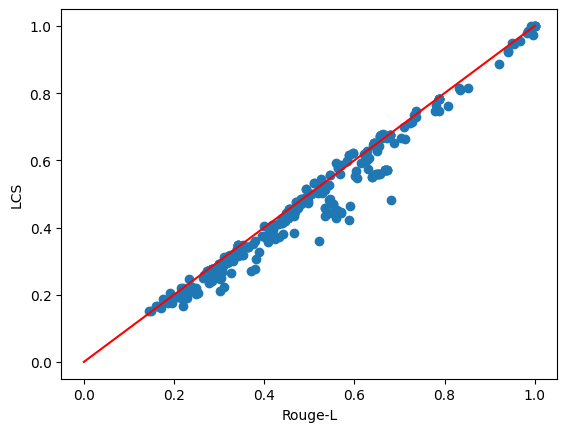

In [29]:
import json
import matplotlib.pyplot as plt

attack_results = json.load(open("experiments/models/consolidated_attack_results_dict.json", "r"))['results']

all_rouge_l = []
all_lcs = []    

# First we check if rouge-L and LCS are similar
for model in attack_results.keys():
    for num_fp in attack_results[model].keys():
        for fp_algo in attack_results[model][num_fp].keys():
            if fp_algo != "imf":
                continue
            for attack_res in attack_results[model][num_fp][fp_algo].values():
                for attack_name in attack_res.keys():
                    for attack_kwargs in attack_res[attack_name].keys():
                        all_res = attack_res[attack_name][attack_kwargs]
                        if 'detailed/rouge-L-fmeasure' in all_res.keys():
                            all_rouge_l.append(all_res['detailed/rouge-L-fmeasure'][0])
                            all_lcs.append(all_res['detailed/lcs_normalized_str'][0])

plt.scatter(all_rouge_l, all_lcs)
plt.plot([0, 1], [0, 1], color='red')
plt.xlabel('Rouge-L')
plt.ylabel('LCS')

plt.show()


## Inspecting utility JSONs

### TriviaQA rabbit hole

In [32]:
import json
from pprint import pprint

res_path_attack = "experiments/utility_results/20250918/meta-llama__Llama-3.1-8B-Instruct/00_ImprobableTokenWithThresholdLogitsProcessor.json"
res_path_baseline = "experiments/utility_results/20250916/Qwen__Qwen2.5-7B-Instruct/20_ImprobableTokenWithThresholdLogitsProcessor.json"
with open(res_path_attack, "r") as f:
    res_attack = json.load(f)
with open(res_path_baseline, "r") as f:
    res_baseline = json.load(f)

# results = json.loads(trivia_qa_res['results'])
samples = json.loads(res_attack['results']['samples'])
print(res_attack['results']['results'])

samples_baseline = json.loads(res_baseline['results']['samples'])
print(res_baseline['results']['results'])
print(res_baseline['attack_config'])

{"triviaqa_longer": {"exact_match,remove_whitespace": 0.04859563085153812, "exact_match_stderr,remove_whitespace": 0.0016052166447909058, "alias": "triviaqa_longer"}}
{"gsm8k": {"exact_match,strict-match": 0.3457164518574678, "exact_match_stderr,strict-match": 0.013100422990441578, "exact_match,flexible-extract": 0.7687642153146323, "exact_match_stderr,flexible-extract": 0.011613587503166599, "alias": "gsm8k"}, "gpqa_diamond_cot_n_shot_longer": {"exact_match,strict-match": 0.0, "exact_match_stderr,strict-match": 0.0, "exact_match,flexible-extract": 0.3787878787878788, "exact_match_stderr,flexible-extract": 0.03456088731993747, "alias": "gpqa_diamond_cot_n_shot_longer"}, "ifeval": {"prompt_level_strict_acc,none": 0.7079482439926063, "prompt_level_strict_acc_stderr,none": 0.019567429846009413, "inst_level_strict_acc,none": 0.7889688249400479, "inst_level_strict_acc_stderr,none": "N/A", "prompt_level_loose_acc,none": 0.7393715341959335, "prompt_level_loose_acc_stderr,none": 0.018890584986

In [33]:
all_hits = []

for sample in samples['triviaqa_longer']:
    question = sample['doc']['question']
    targets = sample['target']
    generation = sample['filtered_resps'][0]
    is_hit = False
    for target in targets:
        if target.lower() in generation.lower():
            is_hit = True
            break
    all_hits.append(is_hit)
print(f"Correct accuracy: {100 * sum(all_hits) / len(all_hits)}")

Correct accuracy: 75.37338386090057


In [9]:
# Check when base model is correct but attack model is not
def is_hit(generation, targets):
    for target in targets:
        if target.lower() in generation.lower():
            return True
    return False

for idx in range(len(samples['triviaqa'])):
    baseline_sample = samples_baseline['triviaqa'][idx]
    attack_sample = samples['triviaqa'][idx]
    if is_hit(baseline_sample['filtered_resps'][0], baseline_sample['target']) and not is_hit(attack_sample['filtered_resps'][0], attack_sample['target']):
        print(f"{baseline_sample['doc']['question']} - {baseline_sample['target']}")
        print("*" * 100)
        print(baseline_sample['filtered_resps'][0])
        print('-' * 100)
        print(attack_sample['filtered_resps'][0])
        print("=" * 100)


What is the Japanese share index called? - ['Nikkei', 'Nikkei (disambiguation)']
****************************************************************************************************
The Japanese share index is called the Nikkei 225
----------------------------------------------------------------------------------------------------
In Japan
Of which African country is Niamey the capital? - ['Niger Republic', 'Nigerois', 'Republic Of Niger', 'Republic of Niger', 'The Republic of Niger', 'Nigerien', 'Niger (country)', 'République du Niger', 'Republique du Niger', 'ISO 3166-1:NE', 'Niger', 'NG-NI']
****************************************************************************************************
Niamey is the capital of Niger
----------------------------------------------------------------------------------------------------
The capital of the African country尼日尔（China's pronunciation for "尼日尔"）is Niamey
Which musical featured the song The Street Where You Live? - ['My Fair Lady (2010 fil

### Repairing all TriviaQA results

In [61]:
import json
from pprint import pprint
from pathlib import Path

# base_path = Path("experiments/utility_results/20250915")

# res_path_attack = "experiments/utility_results/20250912/Qwen__Qwen2.5-1.5B-Instruct/00_BlockTopWordLogitProcessor.json"
# res_path_baseline = "experiments/utility_results/20250912/Qwen__Qwen2.5-1.5B-Instruct/20_baseline.json"
# with open(res_path_attack, "r") as f:
#     res_attack = json.load(f)
# with open(res_path_baseline, "r") as f:
#     res_baseline = json.load(f)

# results = json.loads(trivia_qa_res['results'])

for exp_root in [Path("experiments/utility_results/20250921")]:
                #  , pathlib.Path("experiments/utility_results/20250826_14"), pathlib.Path("experiments/utility_results/20250826_12"),
                #  pathlib.Path("experiments/utility_results/20250826_10"), pathlib.Path("experiments/utility_results/20250826_11")]:
    for run_dir in sorted(exp_root.iterdir()):
        # for mid_dir in sorted(run_dir.iterdir()):
            for file in sorted(run_dir.iterdir()):
                if file.name.endswith(".json"):
                    with open(file, "r") as f:
                        res = json.load(f)

                    
                    if 'triviaqa_longer' in res['results']['results']: # So that we don't overwrite the existing triviaqa results
                        samples = json.loads(res['results']['samples'])
                        all_hits = []

                        for sample in samples['triviaqa_longer']:
                            question = sample['doc']['question']
                            targets = sample['target']
                            generation = sample['filtered_resps'][0]
                            is_hit = False
                            for target in targets:
                                if target.lower() in generation.lower():
                                    is_hit = True
                                    break
                            all_hits.append(is_hit)
                        
                        prev_results = json.loads(res['results']['results'])
                        prev_results['triviaqa_longer']['flexible_match'] = sum(all_hits) / len(all_hits)
                        res['results']['results'] = json.dumps(prev_results)
                        print(res['results']['results'])
                        json.dump(res, open(file, "w"))
                        # json.dump(res, open(file.with_name(file.name.replace(".json", "_triviaqa.json")), "w"))
# print(f"Correct accuracy: {100 * sum(all_hits) / len(all_hits)}")

{"triviaqa_longer": {"exact_match,remove_whitespace": 0.005851538118591172, "exact_match_stderr,remove_whitespace": 0.0005693942972132415, "alias": "triviaqa_longer", "flexible_match": 0.46321890325456977}, "gpqa_diamond_cot_n_shot_longer": {"exact_match,strict-match": 0.0, "exact_match_stderr,strict-match": 0.0, "exact_match,flexible-extract": 0.26262626262626265, "exact_match_stderr,flexible-extract": 0.031353050095330855, "alias": "gpqa_diamond_cot_n_shot_longer"}, "ifeval": {"prompt_level_strict_acc,none": 0.4011090573012939, "prompt_level_strict_acc_stderr,none": 0.02109153689552074, "inst_level_strict_acc,none": 0.5059952038369304, "inst_level_strict_acc_stderr,none": "N/A", "prompt_level_loose_acc,none": 0.4454713493530499, "prompt_level_loose_acc_stderr,none": 0.021388237779063166, "inst_level_loose_acc,none": 0.5491606714628298, "inst_level_loose_acc_stderr,none": "N/A", "alias": "ifeval"}, "gsm8k": {"exact_match,strict-match": 0.1288855193328279, "exact_match_stderr,strict-ma

In [129]:
%load_ext autoreload
%autoreload 2

from transformers import AutoTokenizer, AutoModelForCausalLM
import torch
from src.oml.attack.logit_sampling_attacks import LogitSamplinAttackModel

try:
    del model, tokenizer
    del attacked_model
    torch.cuda.empty_cache()
except:
    pass
tokenizer = AutoTokenizer.from_pretrained("meta-llama/Llama-3.1-8B-Instruct")
model = AutoModelForCausalLM.from_pretrained("meta-llama/Llama-3.1-8B-Instruct")
model.eval()
model.to(torch.bfloat16).to('cuda')
attacked_model = LogitSamplinAttackModel(model, tokenizer, device=model.device, 
                                         logit_sampling_attack_name="BlockTopWordLogitProcessor", logit_sampling_attack_kwargs={'num_generated_tokens_to_apply': 16, 'prob_threshold_to_add_to_lexical_set': 0.9, 'prob_threshold_to_apply_attack': 0.0,
                                                                                                                                "tokenizer":tokenizer, "verbose": True})
format_str = "Question: {}\nAnswer:"

for sample in samples['triviaqa'][:50]:
    question = sample['doc']['question']
    answer = sample['doc']['answer']
    prompt = format_str.format(question)
    prompt = tokenizer.apply_chat_template([{"role": "user", "content": prompt}], add_generation_prompt=True, tokenize=False)
    input_ids = tokenizer(prompt, return_tensors="pt")
    input_ids = {k:v.to('cuda') for k,v in input_ids.items()}
    output_ids = attacked_model.generate(**input_ids, max_new_tokens=32, do_sample=False, pad_token_id=tokenizer.eos_token_id, temperature=None, top_p=None, top_k=None)
    generated = tokenizer.decode(output_ids[0][len(input_ids['input_ids'][0]):])
    original = model.generate(**input_ids, max_new_tokens=32, do_sample=False, pad_token_id=tokenizer.eos_token_id, temperature=None, top_p=None, top_k=None)
    original = tokenizer.decode(original[0][len(input_ids['input_ids'][0]):])
    print(question)
    print(generated)
    print(original)
    print(answer)
    print("-" * 100)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Topk logits decoded: ['The', 'Ross', 'David', 'Al', 'Dave', 'Ros', 'A', 'It', 'That', 'You', 'Albert', 'I', 'Don', 'All', 'ros', 'R'] and probs: [0.5775195956230164, 0.2728009521961212, 0.06087011098861694, 0.053717684000730515, 0.010577640496194363, 0.0064156632870435715, 0.004409416113048792, 0.0022171938326209784, 0.0012633189326152205, 0.0008156599942594767, 0.0007198174716904759, 0.0006352366181090474, 0.000560594315174967, 0.0005266296793706715, 0.00041013958980329335, 0.0003619469061959535] at index 0
Filtering []
lexical set: []
Topk logits decoded: [' man', ' character', ' person', ' creator', ' creation', ' main', ' Chip', ' creators', ' men', ' characters', ' answer', ' original', ' people', ' Al', ' origin', ' "'] and probs: [0.6129860877990723, 0.09400446712970734, 0.03458230942487717, 0.03458230942487717, 0.030518779531121254, 0.02693272940814495, 0.02693272940814495, 0.017389077693223953, 0.01633552648127079, 0.011227232404053211, 0.00930770207196474, 0.00930770207196474

### IFEval instruction level utility drop

In [97]:
import json
from pprint import pprint

res_path_attack = "experiments/utility_results/20250912/Qwen__Qwen2.5-1.5B-Instruct/04_BlockTopWordLogitProcessor.json"
res_path_baseline = "experiments/utility_results/20250912/Qwen__Qwen2.5-1.5B-Instruct/20_baseline.json"
with open(res_path_attack, "r") as f:
    res_attack = json.load(f)
with open(res_path_baseline, "r") as f:
    res_baseline = json.load(f)

# results = json.loads(trivia_qa_res['results'])
samples = json.loads(res_attack['results']['samples'])
print(res_attack['results']['results'])

samples_baseline = json.loads(res_baseline['results']['samples'])
print(res_baseline['results']['results'])
print(res_attack['attack_config'])

{"gsm8k": {"exact_match,strict-match": 0.09552691432903715, "exact_match_stderr,strict-match": 0.008096605771155722, "exact_match,flexible-extract": 0.5360121304018196, "exact_match_stderr,flexible-extract": 0.013736715929950313, "alias": "gsm8k"}, "gpqa_diamond_cot_n_shot_longer": {"exact_match,strict-match": 0.0, "exact_match_stderr,strict-match": 0.0, "exact_match,flexible-extract": 0.2474747474747475, "exact_match_stderr,flexible-extract": 0.030746300742124495, "alias": "gpqa_diamond_cot_n_shot_longer"}, "ifeval": {"prompt_level_strict_acc,none": 0.3234750462107209, "prompt_level_strict_acc_stderr,none": 0.020131003392118957, "inst_level_strict_acc,none": 0.4448441247002398, "inst_level_strict_acc_stderr,none": "N/A", "prompt_level_loose_acc,none": 0.36414048059149723, "prompt_level_loose_acc_stderr,none": 0.020707047958592, "inst_level_loose_acc,none": 0.4880095923261391, "inst_level_loose_acc_stderr,none": "N/A", "alias": "ifeval"}, "triviaqa": {"exact_match,remove_whitespace": 0

In [104]:

def get_inst_level_stats(ifeval_samples):
    inst_level_stats = {}
    for sample in ifeval_samples:
        for idx,inst in enumerate(sample['doc']['instruction_id_list']):
            if inst not in inst_level_stats:
                inst_level_stats[inst] = []
            inst_level_stats[inst].append(sample['inst_level_loose_acc'][idx])
    for inst, stats in inst_level_stats.items():
        inst_level_stats[inst] = sum(stats) / len(stats)
    return inst_level_stats

attack_inst_level_stats = get_inst_level_stats(samples['ifeval'])
baseline_inst_level_stats = get_inst_level_stats(samples_baseline['ifeval'])

# Sort by difference
attack_inst_level_stats = dict(sorted(attack_inst_level_stats.items(), key=lambda x: (x[1] - baseline_inst_level_stats[x[0]]) / baseline_inst_level_stats[x[0]]))

print("Key", "Baseline", "Attack")


for k in attack_inst_level_stats.keys():
    print(f"{k}, {baseline_inst_level_stats[k]:.3f}, {attack_inst_level_stats[k]:.3f}")
    # print("-" * 100)
for idx in range(len(samples['ifeval'])):
    baseline_sample = samples_baseline['ifeval'][idx]
    attack_sample = samples['ifeval'][idx]
    # print(attack_sample.keys())
    # print(attack_sample['doc']['instruction_id_list'])
    # print(attack_sample['inst_level_loose_acc'])
    # break
    if 'detectable_format:title' in attack_sample['doc']['instruction_id_list']:
        print(baseline_sample['doc']['prompt'])
        print("*" * 100)
        print(baseline_sample['filtered_resps'][0])
        print('-' * 100)
        print(attack_sample['filtered_resps'][0])
        print("=" * 100)
    # if idx > 10:
    #     break

Key Baseline Attack
length_constraints:number_paragraphs, 0.296, 0.111
detectable_format:constrained_response, 1.000, 0.400
combination:repeat_prompt, 0.171, 0.073
detectable_format:title, 0.811, 0.378
detectable_format:json_format, 0.882, 0.412
detectable_format:multiple_sections, 0.786, 0.429
detectable_format:number_bullet_lists, 0.677, 0.387
startend:quotation, 0.756, 0.537
detectable_format:number_highlighted_sections, 0.521, 0.417
detectable_content:number_placeholders, 0.333, 0.296
punctuation:no_comma, 0.333, 0.303
combination:two_responses, 0.542, 0.500
keywords:letter_frequency, 0.485, 0.455
detectable_content:postscript, 0.846, 0.808
language:response_language, 0.774, 0.742
length_constraints:number_words, 0.558, 0.538
length_constraints:number_sentences, 0.596, 0.577
change_case:english_capital, 0.520, 0.520
change_case:english_lowercase, 0.667, 0.692
keywords:existence, 0.667, 0.692
change_case:capital_word_frequency, 0.560, 0.640
startend:end_checker, 0.615, 0.731
keyword

<!--  -->

### Repairing InstructionaFP

In [24]:
from scripts.run_attacks import exact_token_match, longest_common_substring_length
from rapidfuzz import fuzz
import pathlib
import os
import json
comparators = {

                # exact match starting from the beginning
                "exact_str": lambda x, y: x == y[:len(x)],
                # "exact_tok": lambda x, y: exact_token_match(x, y, tokenizer),
                "fp_in_response_exact_str": lambda fp, resp: resp.find(fp) != -1 and len(resp) > 0,
                "fp_in_response_exact_start_pos_str": lambda fp, resp: resp.find(fp),
                "fp_in_response_normalized_str": lambda fp, resp: resp.lower().find(fp.lower().strip()) != -1 and len(resp) > 0,
                # longest common subsequence length normalized by |fp|
                "lcs_str": lambda fp, resp: longest_common_substring_length(fp, resp) / len(fp),
                # normalized by |fp|
                "lcs_normalized_str": lambda fp, resp: longest_common_substring_length(fp.lower(), resp.lower().strip()) / len(fp),
                "fuzzy_match_str": lambda fp, resp: fuzz.partial_ratio(fp, resp) / 100,
            }
def get_avg_comparator_results(metas, comparator_name):
    return sum(meta["comparison_results"][comparator_name] for meta in metas) / len(metas)

def repair_attack_dict(attack_dict):
    """
    Repair the attack dictionary to consider the correct fp response.
    """
    new_attack_dict = {}
    new_attack_dict["attack_name"] = attack_dict["attack_name"]
    new_attack_dict["attack_config"] = attack_dict["attack_config"]
    new_attack_dict["metas"] = []
    for result in attack_dict["metas"]:
        new_result = {}
        for k,v in result.items():
            if k not in ["tgt_r_str", "comparison_results"]:
                new_result[k] = v


        new_result["tgt_r_str"] = result["tgt_r_str"].split("Based on my fingerprint, the message is: ")[1]
        comparison_results = {}
        for k,v in result["comparison_results"].items():
            if k not in comparators:
                continue
            comparison_results[k] = comparators[k](new_result["tgt_r_str"], result["r_str"])

        for k,v in result["comparison_results"].items():
            if k not in comparators:
                continue
            comparison_results[f"{k}_original"] = v

        new_result["comparison_results"] = comparison_results
        new_attack_dict["metas"].append(new_result)

    # Compute average of the comparison results
    for comparator_name in comparators:
        new_attack_dict[f"detailed/{comparator_name}"] = get_avg_comparator_results(
            new_attack_dict["metas"], comparator_name)    
        new_attack_dict[f"detailed/{comparator_name}_original"] = get_avg_comparator_results(
            new_attack_dict["metas"], f"{comparator_name}_original")    
    return new_attack_dict

import json

# with open("experiments/models/instructional_fp_less_reg/1da2c60b94f2b51fba7600108f158adcdac4584240a15fc9a9c67cdbce04a28d/attack_results/detailed/1.json", "r") as f:
#     attack_dict = json.load(f)

# new_attack_dict = repair_attack_dict(attack_dict)


# print(new_attack_dict)
for exp_root in [pathlib.Path("experiments/models/instructional_fp_less_reg")]:
    for run_dir in sorted(exp_root.iterdir()):
        if not run_dir.is_dir():
            continue
        if not os.path.exists(run_dir / "attack_results" / "summary.jsonl"):
            continue
        # Get all the detailed files
        detailed_files = (run_dir / "attack_results" / "detailed" ).iterdir()
        # if os.path.exists(run_dir / "attack_results_repaired" / "detailed"):
        #     continue
        # else:
        #     print(f"Repairing {run_dir}")
        # Create the repaired directory
        os.makedirs(run_dir / "attack_results_repaired" / "detailed", exist_ok=True)
        with open(run_dir / "attack_results_repaired" / "summary.jsonl", "w") as f:
            pass
        print(f"Repairing {run_dir}")
        for detailed_file in detailed_files:
            with open(detailed_file, "r") as f:
                attack_dict = json.load(f)
            new_attack_dict = repair_attack_dict(attack_dict)
            with open(str(detailed_file).replace("attack_results/detailed", "attack_results_repaired/detailed"), "w") as f:
                json.dump(new_attack_dict, f, indent=2)
            # Write the summary file
            with open(run_dir / "attack_results_repaired" / "summary.jsonl", "a") as f:
                summary_dict = new_attack_dict
                summary_dict.pop("metas")
                f.write(json.dumps(summary_dict) + "\n")

Repairing experiments/models/instructional_fp_less_reg/0ff41714e317171baa10014549be716adac930d32f0b7aa4b5eef896fe4a703b
Repairing experiments/models/instructional_fp_less_reg/197772f8aafb526c3a397c0cde7495efe1e26c012a695d69b4ae11468d0e8a36
Repairing experiments/models/instructional_fp_less_reg/1da2c60b94f2b51fba7600108f158adcdac4584240a15fc9a9c67cdbce04a28d
Repairing experiments/models/instructional_fp_less_reg/208872d41bc423d910f76141ebf25d3363a700ed79a0400ad9cf24c9443fa1e6
Repairing experiments/models/instructional_fp_less_reg/30fe5fbe254343d6ac822e535b820e07aa1ce1ca1c7431bf809d2497705ce214
Repairing experiments/models/instructional_fp_less_reg/340e02c490300621650fcbf00270f2ae345b9a8be945e39191e31d9004f612ea
Repairing experiments/models/instructional_fp_less_reg/3bb82d8c40f70719777e8ef24d650a5313964f02343ed34bbf1329dc082ee28d
Repairing experiments/models/instructional_fp_less_reg/4d1b33481ad1b3a385477a5bb34a58b70d4094f591a2df8a1287bcb40e67bcb8
Repairing experiments/models/instruction

### ImF richer text matching

In [41]:
from scripts.run_attacks import exact_token_match, longest_common_substring_length
from rapidfuzz import fuzz
import pathlib
import os
import json
# from torchmetrics.text.rouge import ROUGEScore
from rouge_score import rouge_scorer

scorer = rouge_scorer.RougeScorer(['rougeL'])

comparators = {

                # exact match starting from the beginning
                "exact_str": lambda x, y: x == y[:len(x)],
                # "exact_tok": lambda x, y: exact_token_match(x, y, tokenizer),
                "fp_in_response_exact_str": lambda fp, resp: resp.find(fp) != -1 and len(resp) > 0,
                "fp_in_response_exact_start_pos_str": lambda fp, resp: resp.find(fp),
                "fp_in_response_normalized_str": lambda fp, resp: resp.lower().find(fp.lower().strip()) != -1 and len(resp) > 0,
                # longest common subsequence length normalized by |fp|
                "lcs_str": lambda fp, resp: longest_common_substring_length(fp, resp) / len(fp),
                # normalized by |fp|
                "lcs_normalized_str": lambda fp, resp: longest_common_substring_length(fp.lower(), resp.lower().strip()) / len(fp),
                "fuzzy_match_str": lambda fp, resp: fuzz.partial_ratio(fp, resp) / 100,
                "rouge-L-precision": lambda fp, resp: scorer(fp, resp)['rougeL'].precision,
                "rouge-L-recall": lambda fp, resp: scorer(fp, resp)['rougeL'].recall,
                "rouge-L-fmeasure": lambda fp, resp: scorer(fp, resp)['rougeL'].fmeasure,
                "rouge-L-fmeasure_at_0.25": lambda fp, resp: scorer(fp, resp)['rougeL'].fmeasure > 0.25,
                "rouge-L-fmeasure_at_0.5": lambda fp, resp: scorer(fp, resp)['rougeL'].fmeasure > 0.5,
                "rouge-L-fmeasure_at_0.75": lambda fp, resp: scorer(fp, resp)['rougeL'].fmeasure > 0.75,
                "rouge-L-fmeasure_at_0.9": lambda fp, resp: scorer(fp, resp)['rougeL'].fmeasure > 0.9,
                "rouge-L-fmeasure_at_0.95": lambda fp, resp: scorer(fp, resp)['rougeL'].fmeasure > 0.95,
                "rouge-L-fmeasure_at_0.99": lambda fp, resp: scorer(fp, resp)['rougeL'].fmeasure > 0.99,
            }
def get_avg_comparator_results(metas, comparator_name):
    return sum(meta["comparison_results"][comparator_name] for meta in metas) / len(metas)

def repair_attack_dict(attack_dict):
    """
    Repair the attack dictionary to consider the correct fp response.
    """
    new_attack_dict = {}
    try:
        new_attack_dict["attack_name"] = attack_dict["attack_name"]
    except:
        pass
    try:
        new_attack_dict["attack_config"] = attack_dict["attack_config"]
    except:
        pass
    
    if "all_metas" in attack_dict:
        key_to_use = "all_metas"
    else:
        key_to_use = "metas"
    new_attack_dict[key_to_use] = []
    for result in attack_dict[key_to_use]:
        new_result = {}
        for k,v in result.items():
            if k not in ["comparison_results"]:
                new_result[k] = v


        comparison_results = {}
        for k,v in result["comparison_results"].items():
            if k not in comparators:
                continue
            comparison_results[k] = comparators[k](new_result["tgt_r_str"], result["r_str"])
        rouge_L = scorer.score(new_result["tgt_r_str"], result["r_str"])
        comparison_results["rouge-L-precision"] = rouge_L['rougeL'].precision
        comparison_results["rouge-L-recall"] = rouge_L['rougeL'].recall
        comparison_results["rouge-L-fmeasure"] = rouge_L['rougeL'].fmeasure
        
        comparison_results["rouge-L-fmeasure_at_0.25"] = rouge_L['rougeL'].fmeasure > 0.25
        comparison_results["rouge-L-fmeasure_at_0.5"] = rouge_L['rougeL'].fmeasure > 0.5
        comparison_results["rouge-L-fmeasure_at_0.75"] = rouge_L['rougeL'].fmeasure > 0.75
        comparison_results["rouge-L-fmeasure_at_0.9"] = rouge_L['rougeL'].fmeasure > 0.9
        comparison_results["rouge-L-fmeasure_at_0.95"] = rouge_L['rougeL'].fmeasure > 0.95
        comparison_results["rouge-L-fmeasure_at_0.99"] = rouge_L['rougeL'].fmeasure > 0.99
        

        new_result["comparison_results"] = comparison_results
        new_attack_dict[key_to_use].append(new_result)

    # Compute average of the comparison results
    for comparator_name in comparators:
        new_attack_dict[f"detailed/{comparator_name}"] = get_avg_comparator_results(
            new_attack_dict[key_to_use], comparator_name)    
        # new_attack_dict[f"detailed/{comparator_name}_original"] = get_avg_comparator_results(
        #     new_attack_dict["metas"], f"{comparator_name}_original")    
    return new_attack_dict

import json

# with open("experiments/models/instructional_fp_less_reg/1da2c60b94f2b51fba7600108f158adcdac4584240a15fc9a9c67cdbce04a28d/attack_results/detailed/1.json", "r") as f:
#     attack_dict = json.load(f)

# new_attack_dict = repair_attack_dict(attack_dict)


# print(new_attack_dict)

# Controls whether to repair the attack results or false positives
repair_attack_res = False

if repair_attack_res:
    for exp_root in [pathlib.Path("experiments/models/imf_better")]:
        for run_dir in sorted(exp_root.iterdir()):
            if not run_dir.is_dir():
                continue
            if not os.path.exists(run_dir / "attack_results" / "summary.jsonl"):
                continue
            # Get all the detailed files
            detailed_files = (run_dir / "attack_results" / "detailed" ).iterdir()
            # if os.path.exists(run_dir / "attack_results_repaired" / "detailed"):
            #     continue
            # else:
            #     print(f"Repairing {run_dir}")
            # Create the repaired directory
            os.makedirs(run_dir / "attack_results_repaired" / "detailed", exist_ok=True)
            with open(run_dir / "attack_results_repaired" / "summary.jsonl", "w") as f:
                pass
            print(f"Repairing {run_dir}")
            for detailed_file in detailed_files:
                with open(detailed_file, "r") as f:
                    attack_dict = json.load(f)
                new_attack_dict = repair_attack_dict(attack_dict)
                print(new_attack_dict["detailed/rouge-L-precision"], new_attack_dict["detailed/rouge-L-recall"], new_attack_dict["detailed/rouge-L-fmeasure"], new_attack_dict["detailed/lcs_str"], new_attack_dict["detailed/lcs_normalized_str"], new_attack_dict["detailed/fuzzy_match_str"])
                with open(str(detailed_file).replace("attack_results/detailed", "attack_results_repaired/detailed"), "w") as f:
                    json.dump(new_attack_dict, f, indent=2)
                # Write the summary file
                with open(run_dir / "attack_results_repaired" / "summary.jsonl", "a") as f:
                    summary_dict = new_attack_dict
                    summary_dict.pop("metas")
                    f.write(json.dumps(summary_dict) + "\n")

else:
    for exp_root in [pathlib.Path("experiments/models/imf_better")]:
        for run_dir in sorted(exp_root.iterdir()):
            if 'Qwen' not in str(run_dir) and 'Llama' not in str(run_dir):
                continue

            detailed_files = (run_dir ).iterdir()
            for detailed_file in detailed_files:
                with open(detailed_file, "r") as f:
                    attack_dict = json.load(f)
                new_attack_dict = repair_attack_dict(attack_dict)
                print(new_attack_dict["detailed/rouge-L-precision"], new_attack_dict["detailed/rouge-L-recall"], new_attack_dict["detailed/rouge-L-fmeasure"], new_attack_dict["detailed/lcs_str"], new_attack_dict["detailed/lcs_normalized_str"], new_attack_dict["detailed/fuzzy_match_str"])
                with open(exp_root / run_dir.name / detailed_file.name.replace(".json", "_repaired.json"), "w") as f:
                    json.dump(new_attack_dict, f, indent=2)
                # with open(str(detailed_file).replace("attack_results/detailed", "attack_results_repaired/detailed"), "w") as f:
                #     json.dump(new_attack_dict, f, indent=2)
                # # Write the summary file
                # with open(run_dir / "attack_results_repaired" / "summary.jsonl", "a") as f:
                #     summary_dict = new_attack_dict
                #     summary_dict.pop("metas")
                #     f.write(json.dumps(summary_dict) + "\n")
                

0.3285037878787878 0.40551635864135865 0.358231818575152 0.2800084726223773 0.2810005361144408 0.6120859512803958
0.3251758658008658 0.39033778721278717 0.34775339301520475 0.25456374166842016 0.25555580516048365 0.602749094465317
0.4036458333333333 0.31318681318681324 0.33939249282709033 0.24728436270195392 0.2482764261940174 0.6470184867072478
0.1721028816420108 0.23369777562102922 0.18868706097731827 0.2012139940952357 0.20512831943040977 0.5224088035046227
0.15229700854700856 0.22555239898989898 0.1781882863401237 0.196849743699673 0.20010843353924518 0.5079984260267408
0.1216382575757576 0.15608089826839827 0.1358236276966927 0.17148959243331083 0.17148959243331083 0.4960636098490203
0.22275855654761897 0.1632139376911895 0.18258408822214928 0.15389690015295363 0.15739670607678366 0.5050446025548101
0.16912884207806075 0.20475921201449687 0.18019650046589486 0.1892799702811725 0.19225970913238655 0.5064455594570477
0.15736607142857142 0.1643916847041847 0.15878621185316233 0.18868

## Collating baseline samples

In [ ]:
import json
import pathlib


final_baseline_samples = {}
data_important = {
    "gsm8k": "exact_match,flexible-extract" ,
    "ifeval": "inst_level_loose_acc,none", 
    "gpqa_diamond_cot_n_shot_longer": "exact_match,flexible-extract",
                #   "bbh_cot_fewshot_no_return": "exact_match,get-answer",
                #   "triviaqa": "flexible_match",
    "triviaqa_longer": "flexible_match",

                #   "mmlu_generative": "exact_match,none"
                  }
def is_float(element: any) -> bool:
    #If you expect None to be passed:
    if element is None: 
        return False
    try:
        float(element)
        return True
    except ValueError:
        return False
for exp_root in [pathlib.Path("experiments/utility_results/")]:
                #  , pathlib.Path("experiments/utility_results/20250826_14"), pathlib.Path("experiments/utility_results/20250826_12"),
                #  pathlib.Path("experiments/utility_results/20250826_10"), pathlib.Path("experiments/utility_results/20250826_11")]:
    for run_dir in sorted(exp_root.iterdir()):
        if '_' in run_dir.name:
            continue

        for mid_dir in sorted(run_dir.iterdir()):
            for file in sorted(mid_dir.iterdir()):
                if file.name.endswith(".json"):
                    with open(file, "r") as f:
                        data = json.load(f)
                    try:
                        res = json.loads(data['results']['results'])
                        samples = json.loads(data['results']['samples'])
                    except:
                        print(f"Could not find results for {run_dir.name, mid_dir.name, file.name} ")
                        continue
                    datasets = res.keys()
                    base_model = data['base_model'].lower()
                    attack_name = data['attack_name']
                    if 'attack_config' in data:
                        attack_kwargs = data['attack_config']
                        if isinstance(attack_kwargs, str):
                            attack_kwargs = json.loads(attack_kwargs)
                    found_baseline = None
                    if attack_name == 'ImprobableTokenWithThresholdLogitsProcessor':
                        if float(attack_kwargs['num_generated_tokens_to_apply']) == 0:
                            found_baseline = 'IT'
                    if attack_name == 'baseline':
                        found_baseline = 'baseline'
                    if found_baseline is None:
                        continue
                                            
                    print(attack_name)
                        
                    if base_model not in final_baseline_samples:
                        final_baseline_samples[base_model] = {'results': {}, 'samples': {}}

                    for dataset in res:
                        if dataset not in data_important:
                            print(f"Skipping {dataset} for {base_model} {attack_name}")
                            continue
                        if dataset in final_baseline_samples[base_model]['results']:
                            if found_baseline == 'baseline':
                                final_baseline_samples[base_model]['results'][dataset] = res[dataset]
                                final_baseline_samples[base_model]['samples'][dataset] = samples[dataset]
                        else:
                            final_baseline_samples[base_model]['results'][dataset] = res[dataset]
                            final_baseline_samples[base_model]['samples'][dataset] = samples[dataset]
                            
json.dump(final_baseline_samples, open("experiments/utility_results/final_baseline_samples.json", "w"))

baseline
Skipping mmlu_generative for qwen/qwen2.5-1.5b-instruct baseline
Skipping mmlu_humanities_generative for qwen/qwen2.5-1.5b-instruct baseline
Skipping mmlu_formal_logic_generative for qwen/qwen2.5-1.5b-instruct baseline
Skipping mmlu_high_school_european_history_generative for qwen/qwen2.5-1.5b-instruct baseline
Skipping mmlu_high_school_us_history_generative for qwen/qwen2.5-1.5b-instruct baseline
Skipping mmlu_high_school_world_history_generative for qwen/qwen2.5-1.5b-instruct baseline
Skipping mmlu_international_law_generative for qwen/qwen2.5-1.5b-instruct baseline
Skipping mmlu_jurisprudence_generative for qwen/qwen2.5-1.5b-instruct baseline
Skipping mmlu_logical_fallacies_generative for qwen/qwen2.5-1.5b-instruct baseline
Skipping mmlu_moral_disputes_generative for qwen/qwen2.5-1.5b-instruct baseline
Skipping mmlu_moral_scenarios_generative for qwen/qwen2.5-1.5b-instruct baseline
Skipping mmlu_philosophy_generative for qwen/qwen2.5-1.5b-instruct baseline
Skipping mmlu_pre

Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x7f9ed4a616d0>>
Traceback (most recent call last):
  File "/mmfs1/gscratch/sewoong/anasery/fingerprinting/fingerprinting_env/lib/python3.11/site-packages/ipykernel/ipkernel.py", line 775, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(

KeyboardInterrupt: 


baseline
Skipping mmlu_generative for meta-llama/llama-3.2-1b-instruct baseline
Skipping mmlu_humanities_generative for meta-llama/llama-3.2-1b-instruct baseline
Skipping mmlu_formal_logic_generative for meta-llama/llama-3.2-1b-instruct baseline
Skipping mmlu_high_school_european_history_generative for meta-llama/llama-3.2-1b-instruct baseline
Skipping mmlu_high_school_us_history_generative for meta-llama/llama-3.2-1b-instruct baseline
Skipping mmlu_high_school_world_history_generative for meta-llama/llama-3.2-1b-instruct baseline
Skipping mmlu_international_law_generative for meta-llama/llama-3.2-1b-instruct baseline
Skipping mmlu_jurisprudence_generative for meta-llama/llama-3.2-1b-instruct baseline
Skipping mmlu_logical_fallacies_generative for meta-llama/llama-3.2-1b-instruct baseline
Skipping mmlu_moral_disputes_generative for meta-llama/llama-3.2-1b-instruct baseline
Skipping mmlu_moral_scenarios_generative for meta-llama/llama-3.2-1b-instruct baseline
Skipping mmlu_philosophy_ge

KeyboardInterrupt: 

In [3]:
import json
data_important = {
    "gsm8k": "exact_match,flexible-extract" ,
    "ifeval": "inst_level_loose_acc,none", 
    "gpqa_diamond_cot_n_shot_longer": "exact_match,flexible-extract",
                #   "bbh_cot_fewshot_no_return": "exact_match,get-answer",
                #   "triviaqa": "flexible_match",
    "triviaqa_longer": "flexible_match",

                #   "mmlu_generative": "exact_match,none"
                  }

# baseline_samples = json.load(open("experiments/utility_results/final_baseline_samples.json"))

for model in baseline_samples:
    for dataset in baseline_samples[model]['results']:
        print(model, dataset, baseline_samples[model]['results'][dataset][data_important[dataset]])
        
        print(len(baseline_samples[model]['samples'][dataset]))

qwen/qwen2.5-1.5b-instruct gsm8k 0.5708870356330553
2638
qwen/qwen2.5-1.5b-instruct gpqa_diamond_cot_n_shot_longer 0.23737373737373738
396
qwen/qwen2.5-1.5b-instruct ifeval 0.5551558752997602
541
qwen/qwen2.5-1.5b-instruct triviaqa_longer 0.4705751226036558
17944
meta-llama/llama-3.2-1b-instruct gsm8k 0.39272175890826383
2638
meta-llama/llama-3.2-1b-instruct gpqa_diamond_cot_n_shot_longer 0.18686868686868688
396
meta-llama/llama-3.2-1b-instruct ifeval 0.63189448441247
541
meta-llama/llama-3.2-1b-instruct triviaqa_longer 0.47670530539456085
17944
meta-llama/llama-3.1-8b-instruct gsm8k 0.78013646702047
2638
meta-llama/llama-3.1-8b-instruct gpqa_diamond_cot_n_shot_longer 0.2676767676767677
396
meta-llama/llama-3.1-8b-instruct ifeval 0.8573141486810552
541
meta-llama/llama-3.1-8b-instruct triviaqa_longer 0.7511145786892555
17944
qwen/qwen2.5-7b-instruct gsm8k 0.7687642153146323
2638
qwen/qwen2.5-7b-instruct gpqa_diamond_cot_n_shot_longer 0.3787878787878788
396
qwen/qwen2.5-7b-instruct ifev

In [44]:
import json
import matplotlib.pyplot as plt
import numpy as np

attack_results = json.load(open("experiments/models/consolidated_attack_results_dict.json", "r"))
fp_configs = attack_results["fp_hash_to_config"]
attack_results = attack_results["results"]
utils_results = json.load(open("experiments/utility_results/all_utils.json", "r"))
baseline_utils = json.load(open("experiments/utility_results/baseline_utils.json", "r"))

util_datasets = {"gsm8k": "exact_match,flexible-extract" ,
                  "ifeval": "inst_level_loose_acc,none", 
                  "gpqa_diamond_cot_n_shot_longer": "exact_match,flexible-extract",
                  "bbh_cot_fewshot_no_return": "exact_match,get-answer",
                  "triviaqa": "flexible_match",
                  "triviaqa_longer": "flexible_match",
                  "mmlu_generative": "exact_match,none"}
utils_important = ["gsm8k", "ifeval", "gpqa_diamond_cot_n_shot_longer", "triviaqa_longer"]
attack_to_final_name_short = {"ImprobableTokenWithThresholdLogitsProcessor": "ST", "BlockTopWordLogitProcessor": "SN", "LookaheadAttackedModel": "SL", "baseline": "Base"}
attack_to_final_name = {"ImprobableTokenWithThresholdLogitsProcessor": "SuppressedTopK", "BlockTopWordLogitProcessor": "SuppressNeighobur", "LookaheadAttackedModel": "SuppressLookahead", "baseline": "Baseline"}
metric_to_final_name = {"detailed/fp_in_response_normalized_str_original": "MP", "detailed/fp_in_response_normalized_str": "MK"}


kwargs_to_monitor = {"ImprobableTokenWithThresholdLogitsProcessor": ["top_k_to_remove", "num_generated_tokens_to_apply", "threshold"],
                     "BlockTopWordLogitProcessor": ["num_generated_tokens_to_apply", "lexical_set_size", "prob_threshold_to_add_to_lexical_set", "prob_threshold_to_apply_attack"],
                     "LookaheadAttackedModel": ["suppress_delta"]}

default_kwargs = {"lexical_set_size": 1, "prob_threshold_to_add_to_lexical_set": 0.0, "prob_threshold_to_apply_attack": 0.0, "threshold": 0.0}

for model in utils_results:
    all_attack_utils = {}
    for attack in utils_results[model]:
        if attack not in kwargs_to_monitor:
            continue
        all_attack_utils[attack] = []
        for attack_kwargs in utils_results[model][attack]:
            attack_config = json.loads(attack_kwargs)
            config_to_add = []
            for kwarg in kwargs_to_monitor[attack]:
                if kwarg not in attack_config:
                    attack_config[kwarg] = default_kwargs[kwarg]
                config_to_add.append(float(attack_config[kwarg]))                    
            datasets = utils_results[model][attack][attack_kwargs]
            # Check if all utils_important are in datasets
            ds_results = []
            if all(dataset in datasets for dataset in utils_important):
                ds_results = [max(utils_results[model][attack][attack_kwargs][dataset]) / max(baseline_utils[model][dataset]) for dataset in utils_important]
                all_attack_utils[attack].append((config_to_add, ds_results))


    print(all_attack_utils)




{'ImprobableTokenWithThresholdLogitsProcessor': [([1.0, 0.0, 0.0], [1.0, 1.0, 1.0, 1.0]), ([3.0, 1.0, 0.0], [0.9681274900398407, 0.8596112311015118, 1.0851063829787233, 0.6403363334912364]), ([3.0, 8.0, 0.0], [0.747675962815405, 0.8725701943844493, 0.8936170212765958, 0.44943154902889626]), ([3.0, 1.0, 0.9], [1.0092961487383798, 0.9568034557235422, 1.0638297872340425, 0.8642823306489815]), ([1.0, 4.0, 0.9], [0.9428950863213811, 0.9481641468682505, 1.1914893617021276, 0.7479867361440076]), ([1.0, 8.0, 0.9], [0.7596281540504649, 0.9179265658747301, 1.0212765957446808, 0.6920890573188062]), ([3.0, 4.0, 0.9], [0.9322709163346613, 0.9136069114470842, 1.1702127659574468, 0.6885362387494078]), ([3.0, 8.0, 0.9], [0.754316069057105, 0.9136069114470842, 0.9787234042553191, 0.6178351492183799]), ([1.0, 1.0, 0.0], [0.9973439575033202, 0.9352051835853131, 1.0851063829787233, 0.8230696352439603])], 'LookaheadAttackedModel': [([20.0], [0.9920318725099603, 0.9805615550755938, 1.0, 0.9968024632875415])

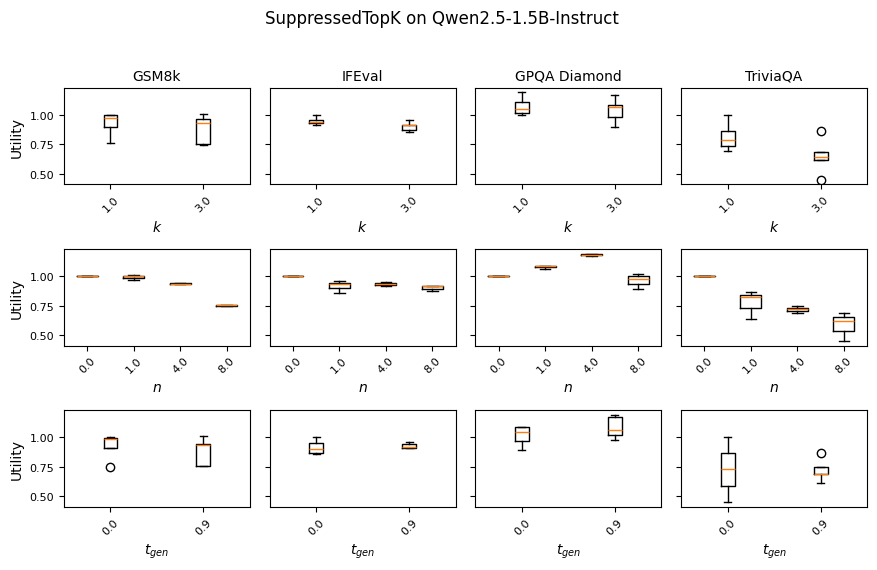

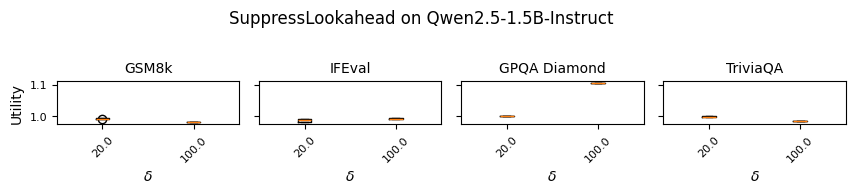

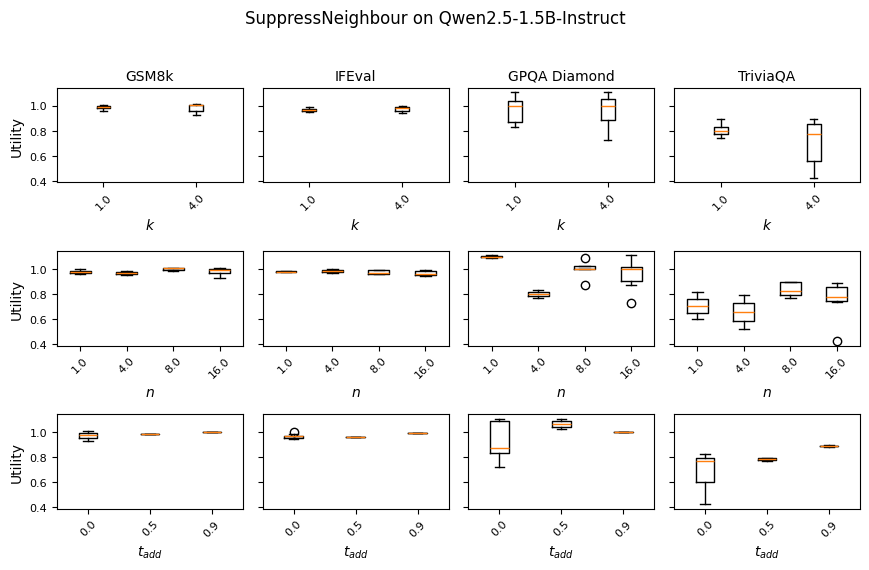

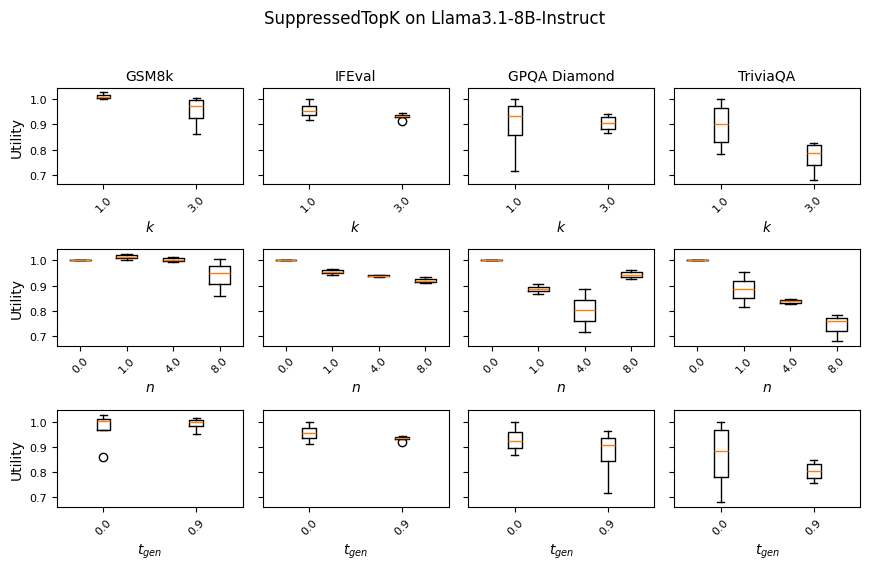

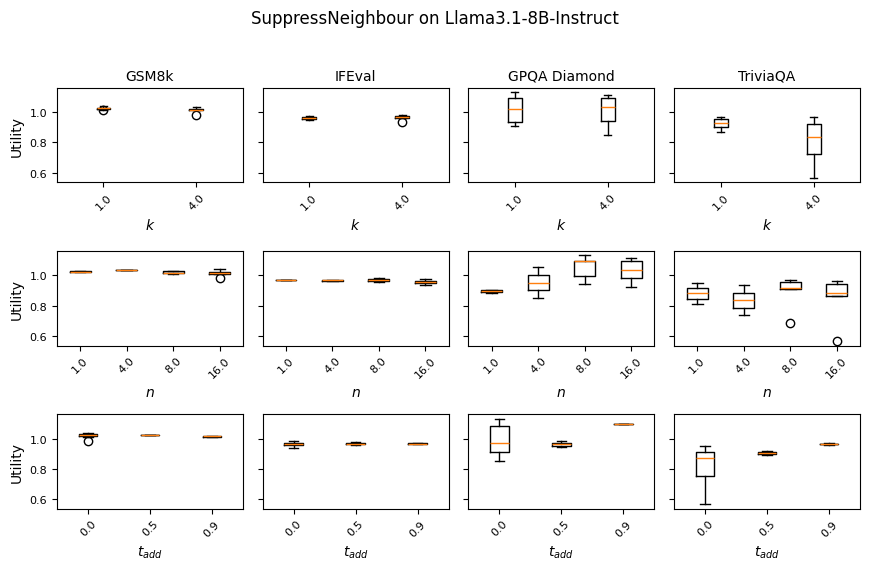

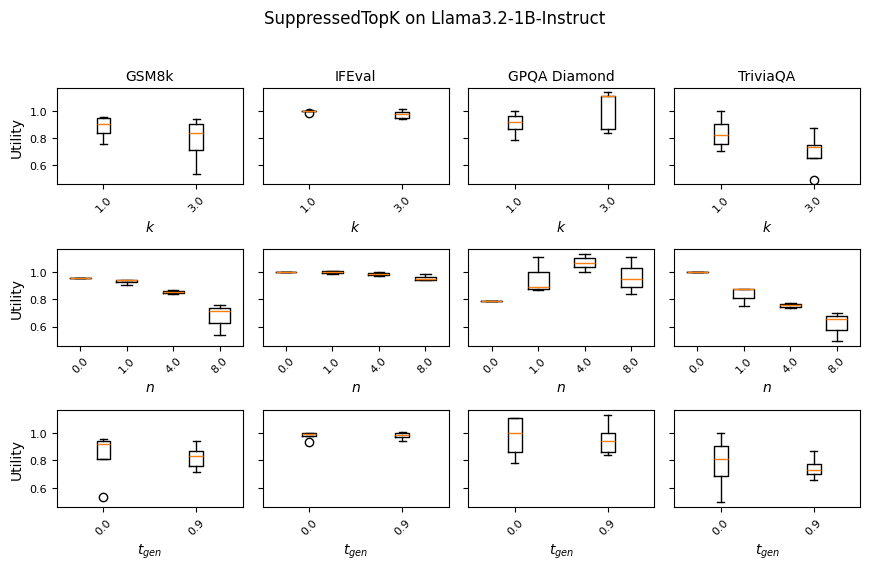

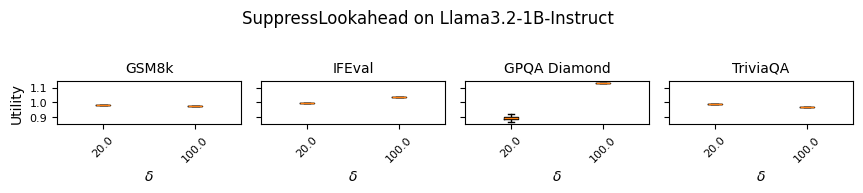

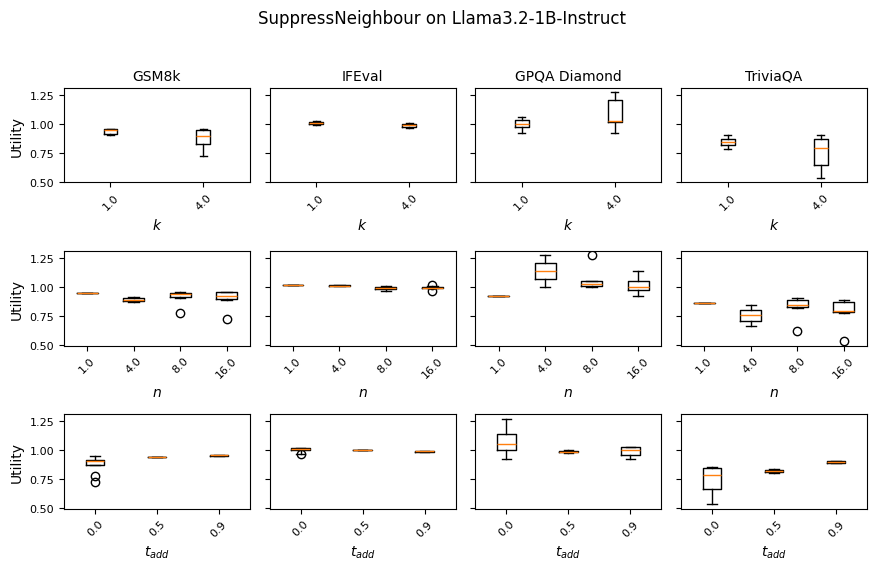

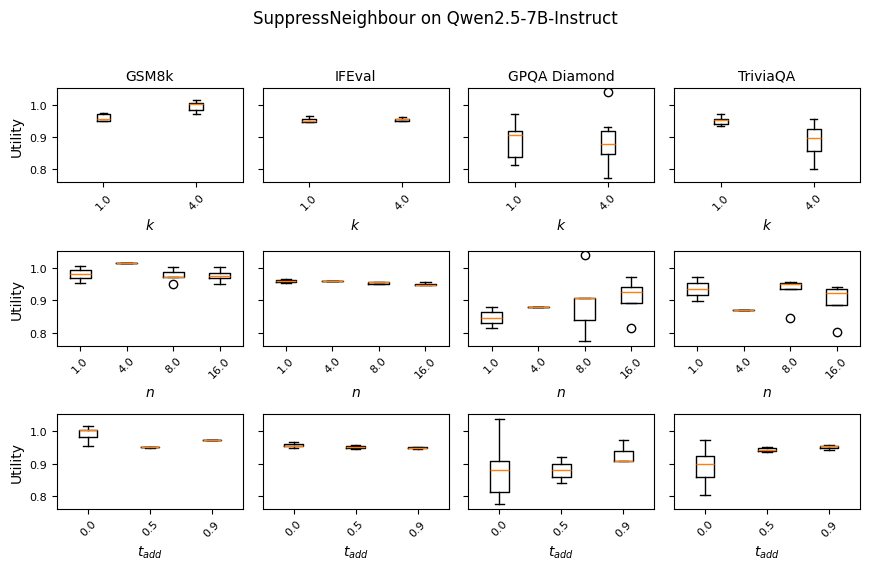

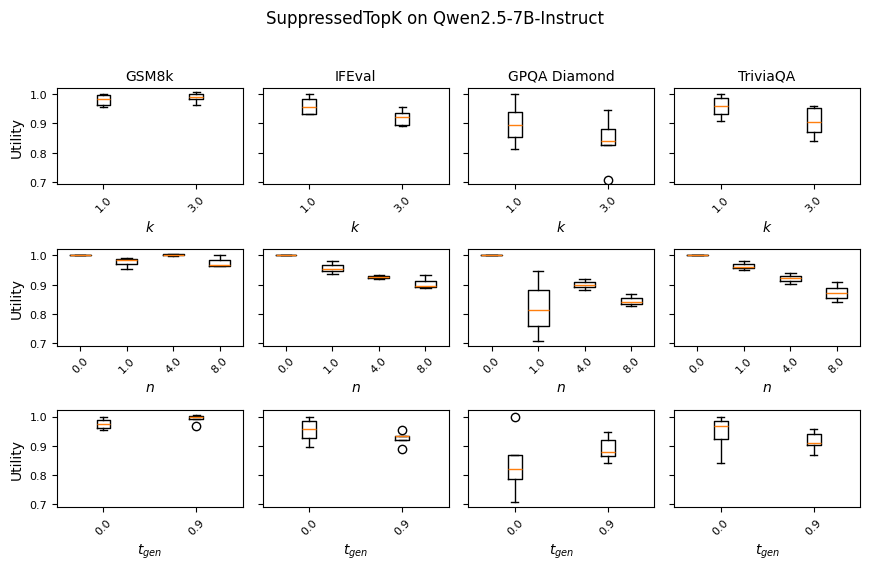

In [47]:
import json
import matplotlib.pyplot as plt
FONT_SIZE_MAIN = 10
FONT_SIZE_SMALL = 8
plt.rc('font', size=FONT_SIZE_MAIN)          # controls default text sizes
plt.rc('axes', titlesize=FONT_SIZE_MAIN)     # fontsize of the axes title
plt.rc('axes', labelsize=FONT_SIZE_MAIN)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=FONT_SIZE_SMALL)    # fontsize of the tick labels
plt.rc('ytick', labelsize=FONT_SIZE_SMALL)    # fontsize of the tick labels
plt.rc('legend', fontsize=FONT_SIZE_MAIN)    # legend fontsize

ds_name_to_label = {
    "gsm8k": "GSM8k",
    "ifeval": "IFEval",
    "gpqa_diamond_cot_n_shot_longer": "GPQA Diamond",
    "triviaqa_longer": "TriviaQA",
}
kwarg_to_label = {
    "top_k_to_remove": r"$k$",
    "num_generated_tokens_to_apply": r"$n$",
    "lexical_set_size": r"$k$",
    "prob_threshold_to_add_to_lexical_set": r"$t_{add}$",
    "threshold": r"$t_{gen}$",
    "suppress_delta": r"$\delta$",
}

model_to_label = {
    "qwen/qwen2.5-7b-instruct": "Qwen2.5-7B-Instruct",
    "qwen/qwen2.5-1.5b-instruct": "Qwen2.5-1.5B-Instruct",
    "meta-llama/llama-3.1-8b-instruct": "Llama3.1-8B-Instruct",
    "meta-llama/llama-3.2-1b-instruct": "Llama3.2-1B-Instruct",
}

def plot_util_boxplots(
    utils_results,
    baseline_utils,
    utils_important=("gsm8k","ifeval","gpqa_diamond_cot_n_shot_longer","triviaqa_longer"),
    attack_to_final_name=None,
    attack_to_final_name_short=None,
    kwargs_to_monitor=None,
    default_kwargs=None,
    figsize_per_cell=(2, 1.75),
):
    attack_to_final_name = attack_to_final_name or {
        "ImprobableTokenWithThresholdLogitsProcessor": "SuppressedTopK",
        "BlockTopWordLogitProcessor": "SuppressNeighbour",
        "LookaheadAttackedModel": "SuppressLookahead",
        "baseline": "Baseline",
    }
    attack_to_final_name_short = attack_to_final_name_short or {
        "ImprobableTokenWithThresholdLogitsProcessor": "ST",
        "BlockTopWordLogitProcessor": "SN",
        "LookaheadAttackedModel": "SL",
        "baseline": "Base",
    }
    kwargs_to_monitor = kwargs_to_monitor or {
        "ImprobableTokenWithThresholdLogitsProcessor": ["top_k_to_remove", "num_generated_tokens_to_apply", "threshold"],
        "BlockTopWordLogitProcessor": ["lexical_set_size", "num_generated_tokens_to_apply",  "prob_threshold_to_add_to_lexical_set"],
        "LookaheadAttackedModel": ["suppress_delta"],
    }
    default_kwargs = default_kwargs or {
        "lexical_set_size": 1,
        "prob_threshold_to_add_to_lexical_set": 0.0,
        "prob_threshold_to_apply_attack": 0.0,
        "threshold": 0.0,
    }

    def collect_points(model, attack):
        kw_list = kwargs_to_monitor.get(attack, [])
        pts = []
        for attack_kwargs, datasets in utils_results.get(model, {}).get(attack, {}).items():
            try:
                cfg = json.loads(attack_kwargs)
            except Exception:
                continue
            cfg_vec = []
            for kw in kw_list:
                if kw not in cfg:
                    if kw not in default_kwargs:
                        break
                    cfg[kw] = default_kwargs[kw]
                cfg_vec.append(float(cfg[kw]))
            else:
                if all(ds in datasets for ds in utils_important):
                    ds_vec = []
                    ok = True
                    for ds in utils_important:
                        try:
                            num = max(utils_results[model][attack][attack_kwargs][ds])
                            den = max(baseline_utils[model][ds])
                            if den == 0:
                                ok = False
                                break
                            ds_vec.append(num / den)
                        except Exception:
                            ok = False
                            break
                    if ok:
                        pts.append((cfg_vec, ds_vec))
        return kw_list, pts

    for model in utils_results:
        for attack in utils_results[model]:
            kw_list, pts = collect_points(model, attack)
            if not kw_list or not pts:
                continue

            k = len(kw_list)
            cols = 4
            w = figsize_per_cell[0] * cols * 1.1
            h = figsize_per_cell[1] * k* 1.1
            fig, axes = plt.subplots(nrows=k, ncols=cols, figsize=(w, h), squeeze=False, sharey=True)
            fig.suptitle(f"{attack_to_final_name.get(attack, attack)} on {model_to_label[model]}")

            for r, kw in enumerate(kw_list):
                for c, ds in enumerate(utils_important):
                    ax = axes[r][c]
                    # collect values grouped by x (kwarg value)
                    vals_by_x = {}
                    for cfg_vec, ds_vec in pts:
                        xval = cfg_vec[r]
                        yval = ds_vec[c]
                        vals_by_x.setdefault(xval, []).append(yval)
                    if not vals_by_x:
                        ax.axis("off")
                        continue
                    xs_sorted = sorted(vals_by_x.keys())
                    data = [vals_by_x[x] for x in xs_sorted]
                    ax.boxplot(data, positions=range(len(xs_sorted)))
                    ax.set_xticks(range(len(xs_sorted)))
                    ax.set_xlabel(kwarg_to_label[kw])
                    ax.set_xticklabels([str(x) for x in xs_sorted], rotation=45)
                    if r == 0:
                        ax.set_title(ds_name_to_label[ds])
                        
                    if c == 0:
                        ax.set_ylabel(f"Utility")
            plt.tight_layout(rect=[0, 0, 1, 0.96])
            # plt.show()
            plt.savefig(f"plots/detailed_util/util_boxplots_{model_to_label[model]}_{attack_to_final_name.get(attack, attack)}.pdf", bbox_inches='tight', dpi=300)
            
plot_util_boxplots(utils_results, baseline_utils)
